# Q3: Cross-Network Model Transferability

**Research Question:** Are DDoS detection models transferable between networks — that is, does a model trained on one real-world network perform acceptably when deployed on a different network it has never seen?

**Why it matters:** In practice, collecting labelled DDoS traffic from every target network is expensive. If models trained on one network generalise to others, a single trained model could be reused across deployment environments. If they do not, each network requires its own training data and model.

**Approach:** Every model is trained on each of the four SCLDDoS2024 networks (SetA–SetD) and evaluated on all four, yielding 16 (train, test) combinations per configuration. In-network performance (train set = test set, diagonal) serves as the upper-bound reference. Cross-network performance (off-diagonal) measures how well the model transfers. The transfer drop = In-network F1 − Cross-network F1.

**Excluded transfers:** SetA and SetC are the *same physical network captured over two different time periods*. The transfers SetA→SetC and SetC→SetA are therefore not genuine cross-network generalisation tests and are excluded throughout: they are blanked and labelled `excl.` in every transfer matrix and figure, and dropped from all cross-network aggregates and statistical tests. This leaves 10 genuine cross-network directed transfers (plus 4 in-network diagonals).

All combinations of model architecture, task type (Binary/Multiclass), split strategy (Random/Time), and feature approach (Sequence/Component) are included.

**Component-based evaluation: per-component and per-event metrics**

Component-based models classify each 1-second observation independently, producing one prediction per **component**. Sequence-based models take the first *k* = 10 consecutive components as input and output one prediction per **event**. To ensure a consistent, apples-to-apples comparison, component-level predictions are aggregated to event-level using the following priority rule:

- **Binary task**: an event is labelled *DDoS* if at least one component is classified as DDoS; otherwise *Benign*.
- **Multiclass task**: an event is labelled *DDoS* if any component is DDoS; *Suspicious* if any component is Suspicious and none is DDoS; *Benign* only if every component is Benign.

Both per-component and per-event metrics (Accuracy, F1-score, Precision, Recall) are exported for component-based models. The **per-event** results are used throughout this analysis. See `evaluation_event_metrics.py` for the full implementation.

**Key finding:** Models are generally *not* transferable. After excluding the same-network SetA↔SetC transfers, the mean transfer drop is 0.22 F1 points, and 68.8% of model configurations show a statistically significant drop (Wilcoxon signed-rank, p < 0.05; mean Cohen's d = 2.55). The drop is highly network-dependent: modest for SetA (+0.06) and SetC (+0.05) but severe for SetD (+0.53) and SetB (+0.22). The best surviving cross-network pair is SetC→SetB (F1 = 0.70) and the worst is SetD→SetA (F1 = 0.40). Cross-network generalisation remains a major open challenge for ML-based DDoS detection.

The following setup cell imports the required Python libraries and configures the visual style and directory structure used throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon
from itertools import product
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR   = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR   = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
NETWORKS = ['SetA', 'SetB', 'SetC', 'SetD']
METRICS  = ['f1_score', 'accuracy', 'precision', 'recall']
PRIMARY  = 'f1_score'

ALL_MODELS = ['gru', 'knn', 'lightgbm', 'logistic-regression', 'lstm',
              'mlp', 'nn', 'random-forest', 'rnn', 'svm', 'xgboost']

# Colour palette for in-network vs cross-network
EVAL_PALETTE = {'In-network': '#4CAF50', 'Cross-network': '#FF5722'}

# ── Excluded transfers ──────────────────────────────────────────────────────
# SetA and SetC are the SAME physical network captured at different time periods.
# Cross-network transfer between them (SetA->SetC and SetC->SetA) is therefore not
# a genuine cross-network generalisation test and is excluded from every
# cross-network aggregate, statistical test, and matrix cell in this analysis.
EXCLUDED_PAIRS = {('SetA', 'SetC'), ('SetC', 'SetA')}


def drop_excluded_pairs(df, train_col='train_set', test_col='test_set'):
    """Return `df` without the same-network/different-time transfers (SetA<->SetC)."""
    keep = ~df.apply(lambda r: (r[train_col], r[test_col]) in EXCLUDED_PAIRS, axis=1)
    return df[keep].copy()


def mark_excluded_cells(ax, row_order, col_order, style='seaborn',
                        color='#d9d9d9', text='excl.'):
    """Overlay a grey patch + italic label on excluded (train, test) heatmap cells.

    style='seaborn' -> cell (i, j) spans [j, j+1] x [i, i+1] (sns.heatmap).
    style='imshow'  -> cell centred at (j, i) (ax.imshow).
    """
    for tr, te in EXCLUDED_PAIRS:
        if tr in row_order and te in col_order:
            i, j = row_order.index(tr), col_order.index(te)
            x0, y0 = (j, i) if style == 'seaborn' else (j - 0.5, i - 0.5)
            cx, cy = (j + 0.5, i + 0.5) if style == 'seaborn' else (j, i)
            ax.add_patch(plt.Rectangle((x0, y0), 1, 1, fill=True,
                                       color=color, lw=0, zorder=3))
            ax.text(cx, cy, text, ha='center', va='center',
                    fontsize=9, fontstyle='italic', color='#555', zorder=4)

All required libraries are imported and the global visual theme is configured. Output directories for figures and tables are created. The analysis environment is ready.

The next cell loads the experiment results CSV and reshapes it from wide to long format. It extracts all train-set/test-set metric combinations, adds an `eval_type` flag, and prepares the data for the transferability analysis.

In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH, index_col=0)
raw = raw[raw['split'] != "Random with same distribution"]

# ── Parse metric columns into long form ───────────────────────────────────────
metric_cols = [c for c in raw.columns if c.count('/') == 2]
id_vars = ['model', 'task', 'split', 'enable_sequences', 'run_no']

long = raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='metric_key', value_name='value'
)
long[['train_set', 'test_set', 'metric']] = long['metric_key'].str.split('/', expand=True)
long = long.drop(columns='metric_key')

# Flag in-network vs cross-network evaluation
long['eval_type'] = np.where(
    long['train_set'] == long['test_set'], 'In-network', 'Cross-network'
)

# Exclude same-network/different-time transfers (SetA<->SetC) from all views
long = drop_excluded_pairs(long)

# Separate views
inset  = long[long['eval_type'] == 'In-network'].copy()
cross  = long[long['eval_type'] == 'Cross-network'].copy()
f1_all = long[long['metric'] == PRIMARY].copy()

print(f"Long-form rows (all):           {len(long):,}")
print(f"Long-form rows (in-network):    {len(inset):,}")
print(f"Long-form rows (cross-network): {len(cross):,}")
print(f"F1-score rows:                  {len(f1_all):,}")
print("\nTrain × Test pairs (unique):")
print(long.groupby(['train_set','test_set','eval_type'])['value'].count().reset_index(
).to_string(index=False))

Long-form rows (all):           33,712
Long-form rows (in-network):    9,632
Long-form rows (cross-network): 24,080
F1-score rows:                  8,428

Train × Test pairs (unique):
train_set test_set     eval_type  value
     SetA     SetA    In-network   2408
     SetA     SetB Cross-network   2408
     SetA     SetD Cross-network   2408
     SetB     SetA Cross-network   2408
     SetB     SetB    In-network   2408
     SetB     SetC Cross-network   2408
     SetB     SetD Cross-network   2408
     SetC     SetB Cross-network   2408
     SetC     SetC    In-network   2408
     SetC     SetD Cross-network   2408
     SetD     SetA Cross-network   2408
     SetD     SetB Cross-network   2408
     SetD     SetC Cross-network   2408
     SetD     SetD    In-network   2408


The dataset is loaded and parsed into a tidy long-format DataFrame. Each row contains a model's F1 score for a specific (run, task, split, approach) setting when trained on one network and evaluated on another. The `eval_type` column distinguishes in-network from cross-network entries.

The next cell averages F1 scores across multiple training runs for each configuration, collapsing run-level variance. It also separates in-network (train_set == test_set) from cross-network (train_set ≠ test_set) entries for downstream analysis.

In [3]:
# ── Average across runs (per configuration) ────────────────────────────────────
group_keys = ['model', 'task', 'split', 'enable_sequences',
              'train_set', 'test_set', 'eval_type', 'metric']

avg = (long.groupby(group_keys, as_index=False)['value']
           .agg(['mean', 'std', 'count'])
           .rename(columns={'mean': 'mean_value', 'std': 'std_value',
                            'count': 'n_runs'}))

avg_f1 = avg[avg['metric'] == PRIMARY].copy()

print("Averaged rows (all metrics):", len(avg))
print("Averaged rows (F1 only):",     len(avg_f1))
print(avg_f1.head(4))

Averaged rows (all metrics): 3808
Averaged rows (F1 only): 952
   model    task         split  enable_sequences train_set test_set  \
1    gru  Binary  Random split              True      SetA     SetA   
5    gru  Binary  Random split              True      SetA     SetB   
9    gru  Binary  Random split              True      SetA     SetD   
13   gru  Binary  Random split              True      SetB     SetA   

        eval_type    metric  mean_value  std_value  n_runs  
1      In-network  f1_score    0.801669   0.016851      10  
5   Cross-network  f1_score    0.522501   0.008933      10  
9   Cross-network  f1_score    0.726382   0.039461      10  
13  Cross-network  f1_score    0.403561   0.002492      10  


The aggregated DataFrame now contains one row per (model, task, split, approach, train_set, test_set) configuration with its mean F1. Each row is labelled as either in-network or cross-network, enabling direct comparison in the subsequent tables and figures.

The next cell produces Table 1, the high-level comparison between in-network and cross-network mean F1. It collapses all model-network combinations into a single number for each evaluation type, giving the overall transferability picture.

In [4]:
# ── Table 1: Overall transferability — In-network vs Cross-network ─────────────
t1_data = avg_f1.copy()

t1 = (t1_data.groupby(['eval_type', 'task'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t1_pivot = t1.pivot_table(
    index='task', columns='eval_type', values='Mean F1'
).reset_index()
t1_pivot.columns.name = None

for col in ['In-network', 'Cross-network']:
    if col not in t1_pivot.columns:
        t1_pivot[col] = np.nan

t1_pivot['Transfer Drop (In − Cross)'] = (
    t1_pivot['In-network'] - t1_pivot['Cross-network']
).round(4)
t1_pivot['Relative Drop (%)'] = (
    (t1_pivot['Transfer Drop (In − Cross)'] / t1_pivot['In-network']) * 100
).round(2)
t1_pivot = t1_pivot.round({'In-network': 4, 'Cross-network': 4})

# Add All-tasks summary row
all_row = pd.DataFrame([{
    'task': 'All',
    'In-network':    t1_data[t1_data['eval_type']=='In-network']['mean_value'].mean(),
    'Cross-network': t1_data[t1_data['eval_type']=='Cross-network']['mean_value'].mean(),
}])
all_row['Transfer Drop (In − Cross)'] = (
    all_row['In-network'] - all_row['Cross-network']).round(4)
all_row['Relative Drop (%)'] = (
    (all_row['Transfer Drop (In − Cross)'] / all_row['In-network']) * 100).round(2)
t1_out = pd.concat([t1_pivot, all_row], ignore_index=True).round(4)

print("Table 1: Overall Transferability — In-network vs Cross-network F1")
print(t1_out.to_string(index=False))
t1_out.to_csv(TAB_DIR / 'table1_overall_transferability.csv', index=False)

latex1 = t1_out.to_latex(index=False, float_format='%.4f',
    caption=r'Overall mean F1-score: in-network (train and test on same set) vs.\ '
            r'cross-network evaluation (averaged over all models, tasks, splits, '
            r'and approaches). Transfer Drop = In-network $-$ Cross-network.',
    label='tab:q3_overall')
(TAB_DIR / 'table1_overall_transferability.tex').write_text(latex1)
print("Saved Table 1.")

Table 1: Overall Transferability — In-network vs Cross-network F1
      task  Cross-network  In-network  Transfer Drop (In − Cross)  Relative Drop (%)
    Binary         0.6066      0.8220                      0.2154              26.20
Multiclass         0.4580      0.7273                      0.2693              37.03
       All         0.5323      0.7747                      0.2423              31.28
Saved Table 1.


Table 1 provides the headline result: overall mean in-network F1, overall mean cross-network F1, and the difference (transfer drop). This single comparison establishes whether cross-network transfer is feasible as a general strategy.

The next cell constructs Table 2, the complete transfer matrix showing mean F1 for every (train network, test network) combination. This is the central result table for understanding the full pattern of cross-network generalisation.

In [5]:
# ── Table 2: Transferability matrix — mean F1 per (train_set × test_set) ───────
# Averaged over all models, tasks, splits, approaches
t2_data = avg_f1.copy()

t2_matrix = (t2_data.groupby(['train_set', 'test_set'], as_index=False)['mean_value']
             .mean()
             .rename(columns={'mean_value': 'Mean F1'}))

t2_pivot = t2_matrix.pivot(index='train_set', columns='test_set', values='Mean F1')
t2_pivot = t2_pivot.reindex(index=NETWORKS, columns=NETWORKS).round(4)

# Add row summaries
t2_pivot['In-network']    = t2_pivot.values.diagonal()
mask_off = ~np.eye(len(NETWORKS), dtype=bool)
t2_pivot['Mean Cross']    = [np.nanmean(t2_pivot.loc[r, NETWORKS].values[
    [i for i, c in enumerate(NETWORKS) if c != r]])
    for r in NETWORKS]
t2_pivot['Transfer Drop'] = (t2_pivot['In-network'] - t2_pivot['Mean Cross']).round(4)
t2_pivot = t2_pivot.round(4)

print("Table 2: Mean F1 Transfer Matrix (rows = train set, cols = test set)")
print(t2_pivot.to_string())
t2_pivot.to_csv(TAB_DIR / 'table2_transfer_matrix.csv')

latex2 = t2_pivot.to_latex(float_format='%.4f', na_rep='---',
    caption=r'Mean F1-score transfer matrix (rows = train set, columns = test set), '
            r'averaged over all models, tasks, splits, and approaches. '
            r'Diagonal entries are in-network; off-diagonal are cross-network. '
            r'The SetA$\leftrightarrow$SetC transfers are excluded (same network, '
            r'different capture period) and shown as \texttt{---}. '
            r'Transfer Drop = In-network $-$ Mean Cross.',
    label='tab:q3_matrix')
(TAB_DIR / 'table2_transfer_matrix.tex').write_text(latex2)
print("Saved Table 2.")

Table 2: Mean F1 Transfer Matrix (rows = train set, cols = test set)
test_set     SetA    SetB    SetC    SetD  In-network  Mean Cross  Transfer Drop
train_set                                                                       
SetA       0.6149  0.4825     NaN  0.6464      0.6149      0.5644         0.0504
SetB       0.4384  0.8063  0.6194  0.5747      0.8063      0.5442         0.2621
SetC          NaN  0.7017  0.7528  0.6150      0.7528      0.6584         0.0945
SetD       0.4030  0.4138  0.4284  0.9246      0.9246      0.4151         0.5095
Saved Table 2.


Table 2 presents the full 4×4 transfer matrix of mean F1 scores (16 entries: 4 training networks × 4 test networks). Diagonal values are in-network results; off-diagonal values show cross-network transfer. The matrix reveals which source-target pairs are easiest and hardest.

The next cell constructs Table 3, a per-model breakdown of in-network and cross-network F1 sorted by transfer drop. It identifies which individual model architectures generalise best and worst across networks.

In [6]:
# ── Table 3: Per-model transferability ────────────────────────────────────────
t3_data = avg_f1.copy()

t3 = (t3_data.groupby(['model', 'eval_type'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))

t3_pivot = t3.pivot_table(
    index='model', columns='eval_type', values='Mean F1'
).reset_index()
t3_pivot.columns.name = None

for col in ['In-network', 'Cross-network']:
    if col not in t3_pivot.columns:
        t3_pivot[col] = np.nan

t3_pivot['Transfer Drop'] = (
    t3_pivot['In-network'] - t3_pivot['Cross-network']
).round(4)
t3_pivot['Relative Drop (%)'] = (
    (t3_pivot['Transfer Drop'] / t3_pivot['In-network']) * 100
).round(2)
t3_pivot = t3_pivot.sort_values('Transfer Drop', ascending=True).round(4)

print("Table 3: Per-Model Transferability (sorted by Transfer Drop, best first)")
print(t3_pivot.to_string(index=False))
t3_pivot.to_csv(TAB_DIR / 'table3_per_model_transferability.csv', index=False)

latex3 = t3_pivot.to_latex(index=False, float_format='%.4f',
    caption=r'Per-model mean F1-score: in-network vs.\ cross-network evaluation '
            r'(averaged over all networks, tasks, splits, and approaches), '
            r'sorted by transfer drop (ascending = most transferable first).',
    label='tab:q3_per_model')
(TAB_DIR / 'table3_per_model_transferability.tex').write_text(latex3)
print("Saved Table 3.")

Table 3: Per-Model Transferability (sorted by Transfer Drop, best first)
              model  Cross-network  In-network  Transfer Drop  Relative Drop (%)
logistic-regression         0.5582      0.6968         0.1386              19.89
                mlp         0.5592      0.7721         0.2129              27.57
      random-forest         0.5940      0.8072         0.2132              26.41
           lightgbm         0.5939      0.8105         0.2166              26.72
            xgboost         0.5897      0.8088         0.2191              27.09
                gru         0.5979      0.8396         0.2417              28.79
                rnn         0.5853      0.8327         0.2473              29.70
                svm         0.3936      0.6779         0.2843              41.94
                knn         0.4577      0.7606         0.3029              39.82
               lstm         0.4992      0.8291         0.3299              39.79
                 nn         0.4337  

Table 3 ranks models by the magnitude of their transfer drop (In-network − Cross-network F1). This reveals which architectures are most and least robust to deployment on unseen network environments, with deep learning and classical models compared.

The next cell performs Wilcoxon signed-rank tests (paired by model) to formally test whether the in-network vs cross-network F1 difference is statistically significant, stratified by experimental condition. This yields Table 4.

In [7]:
# ── Table 4: Statistical tests — Wilcoxon (in-network > cross-network) ─────────
def cohens_d(a, b):
    """Cohen's d for paired samples."""
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

model_records = []
for model, task, split, train_net in product(
    ALL_MODELS, avg_f1['task'].unique(), avg_f1['split'].unique(), NETWORKS
):
    in_sub = avg_f1[
        (avg_f1['model'] == model) & (avg_f1['task'] == task) &
        (avg_f1['split'] == split) & (avg_f1['train_set'] == train_net) &
        (avg_f1['test_set'] == train_net)
    ]
    cross_sub = avg_f1[
        (avg_f1['model'] == model) & (avg_f1['task'] == task) &
        (avg_f1['split'] == split) & (avg_f1['train_set'] == train_net) &
        (avg_f1['test_set'] != train_net)
    ]
    if len(in_sub) == 0 or len(cross_sub) == 0:
        continue
    in_val    = float(in_sub['mean_value'].values[0])
    cross_val = float(cross_sub['mean_value'].mean())
    model_records.append({
        'model': model, 'task': task, 'split': split, 'train_set': train_net,
        'mean_in':       in_val,
        'mean_cross':    cross_val,
        'transfer_drop': in_val - cross_val
    })

model_df = pd.DataFrame(model_records)

records = []
for task, split, train_net in product(
    model_df['task'].unique(), model_df['split'].unique(), NETWORKS
):
    sub = model_df[
        (model_df['task'] == task) &
        (model_df['split'] == split) &
        (model_df['train_set'] == train_net)
    ]
    if len(sub) < 2:
        continue
    try:
        stat, p = wilcoxon(sub['mean_in'].values, sub['mean_cross'].values,
                           alternative='greater')
    except ValueError:
        stat, p = np.nan, np.nan
    d = cohens_d(sub['mean_in'].values, sub['mean_cross'].values)
    for _, row in sub.iterrows():
        records.append({
            'model':         row['model'],
            'task':          task,
            'split':         split,
            'train_set':     train_net,
            'n_pairs':       len(sub),
            'mean_in':       row['mean_in'],
            'mean_cross':    row['mean_cross'],
            'transfer_drop': row['transfer_drop'],
            'wilcoxon_stat': float(stat) if not np.isnan(stat) else np.nan,
            'p_value':       float(p)    if not np.isnan(p)    else np.nan,
            'cohens_d':      float(d),
            'significant':   bool(p < 0.05) if not np.isnan(p) else False
        })

stat_df = pd.DataFrame(records).round(4)

summary_stats = (stat_df.groupby(['train_set', 'task'])
    .agg(
        mean_transfer_drop=('transfer_drop', 'mean'),
        pct_significant=('significant', 'first'),
        mean_cohens_d=('cohens_d', 'first'),
        n_tests=('model', 'count')
    ).round(4).reset_index())

print("Table 4: Statistical Tests Summary (per train network × task)")
print(summary_stats.to_string(index=False))

stat_df.to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
summary_stats.to_csv(TAB_DIR / 'table4_statistical_tests.csv', index=False)

latex4 = summary_stats.to_latex(index=False, float_format='%.4f',
    caption=r'Statistical comparison of in-network vs.\ cross-network performance '
            r'per training network and task: mean transfer drop '
            r'(In-network $-$ mean Cross-network F1), significant drop '
            r"(Wilcoxon across models, $p<0.05$), and Cohen's $d$.",
    label='tab:q3_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print(f"\nTotal configuration rows: {len(stat_df)}")
print(f"Conditions with significant drop: {stat_df.drop_duplicates(['task','split','train_set'])['significant'].sum()}")
print("Saved Table 4.")

Table 4: Statistical Tests Summary (per train network × task)
train_set       task  mean_transfer_drop  pct_significant  mean_cohens_d  n_tests
     SetA     Binary              0.0645             True         1.3495       22
     SetA Multiclass              0.0633             True         1.3833       22
     SetB     Binary              0.1363             True         1.0043       22
     SetB Multiclass              0.3051             True         2.6918       22
     SetC     Binary              0.0747             True         0.6518       22
     SetC Multiclass              0.0351             True         1.3897       22
     SetD     Binary              0.4892             True         6.0780       22
     SetD Multiclass              0.5656             True         9.9346       22

Total configuration rows: 176
Conditions with significant drop: 11
Saved Table 4.


Table 4 reports Wilcoxon signed-rank test p-values and Cohen's d values testing whether cross-network F1 is significantly lower than in-network F1. Results are stratified by split type and approach, with significance flags at p < 0.05.

The next cell generates Figure 1, side-by-side transfer matrix heatmaps for the two feature approaches. The heatmaps allow immediate visual comparison of generalisation patterns across all network pairs.

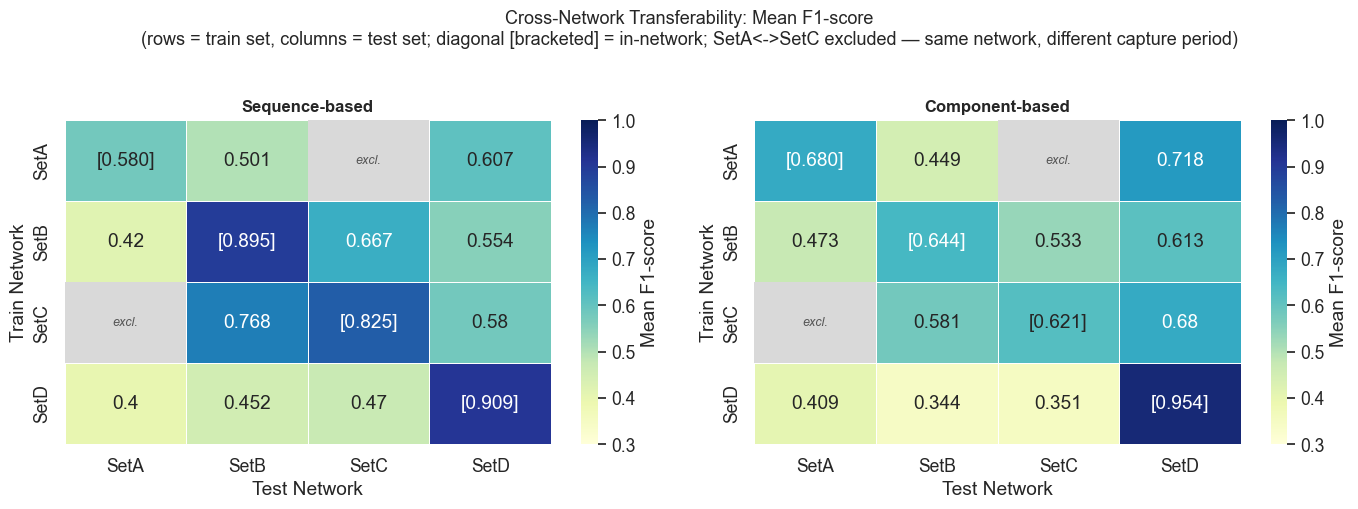

Saved Figure 1.


In [8]:
# ── Figure 1: Heatmap of mean F1 transfer matrix (per approach) ───────────────
f1_avg_pair = (avg_f1.groupby(['train_set', 'test_set', 'enable_sequences'],
                               as_index=False)['mean_value'].mean())
f1_avg_pair['approach'] = f1_avg_pair['enable_sequences'].map(
    {True: 'Sequence-based', False: 'Component-based'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, approach in zip(axes, ['Sequence-based', 'Component-based']):
    pivot = (f1_avg_pair[f1_avg_pair['approach'] == approach]
             .pivot(index='train_set', columns='test_set', values='mean_value')
             .reindex(index=NETWORKS, columns=NETWORKS))

    # Excluded SetA<->SetC cells are masked; diagonal gets a bracketed annotation
    excl_mask = pivot.isna()
    annot = pivot.round(3).astype(str)
    for i in range(len(NETWORKS)):
        if not np.isnan(pivot.iloc[i, i]):
            annot.iloc[i, i] = f"[{pivot.iloc[i, i]:.3f}]"

    sns.heatmap(pivot, annot=annot, fmt='', cmap='YlGnBu',
                vmin=0.3, vmax=1.0, ax=ax, linewidths=0.5, mask=excl_mask,
                cbar_kws={'label': 'Mean F1-score'})
    mark_excluded_cells(ax, NETWORKS, NETWORKS)
    ax.set_title(approach, fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Network')
    ax.set_ylabel('Train Network')

fig.suptitle(
    'Cross-Network Transferability: Mean F1-score\n'
    '(rows = train set, columns = test set; diagonal [bracketed] = in-network; '
    'SetA<->SetC excluded — same network, different capture period)',
    fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_heatmap_transfer_matrix.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig1_heatmap_transfer_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 1.")

Figure 1 renders two transfer matrix heatmaps (one for sequences, one for components), where each cell shows the mean F1 when a model trained on the row network is evaluated on the column network. Diagonal cells represent in-network performance; off-diagonal cells reveal cross-network generalisation.

The next cell produces Figure 2, a four-panel boxplot comparing in-network and cross-network F1 distributions per training network. It provides a direct visual measure of the transferability gap.

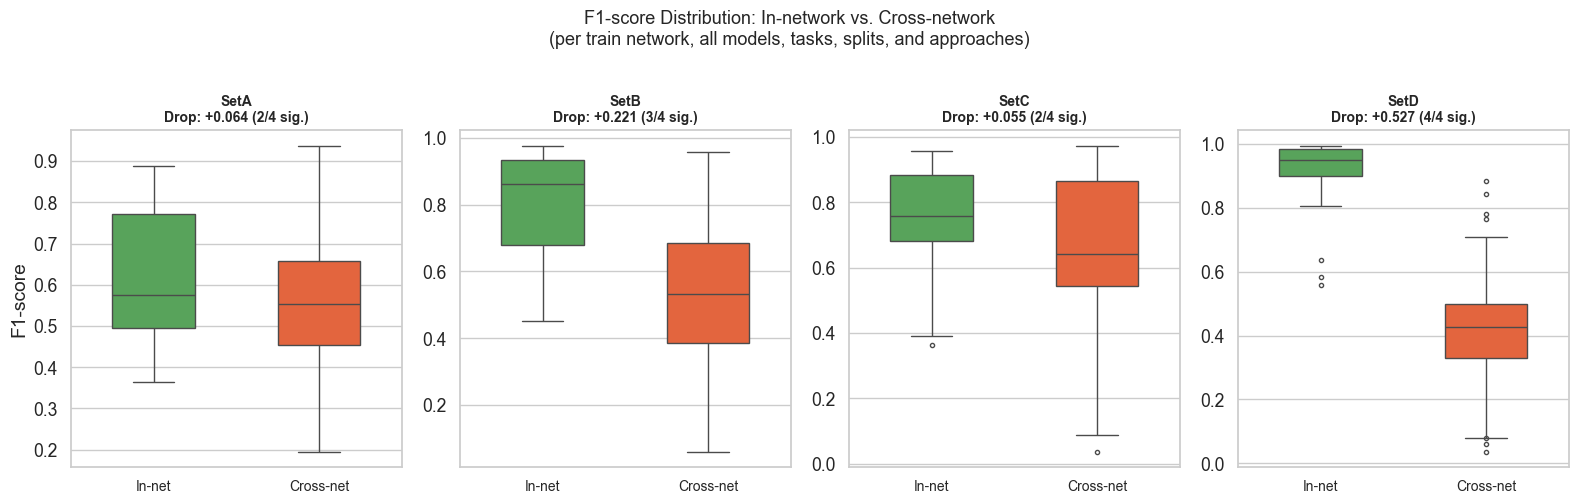

Saved Figure 2.


In [9]:
# ── Figure 2: Boxplot — In-network vs Cross-network F1 per train network ───────
plot_data = avg_f1.copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
for ax, net in zip(axes, NETWORKS):
    sub = plot_data[plot_data['train_set'] == net]
    sns.boxplot(data=sub, x='eval_type', y='mean_value', hue='eval_type',
                palette=EVAL_PALETTE, ax=ax, width=0.5, fliersize=3,
                order=['In-network', 'Cross-network'], legend=False)
    ax.set_xlabel('')
    ax.set_ylabel('F1-score' if ax is axes[0] else '')

    net_stat  = stat_df[stat_df['train_set'] == net].drop_duplicates(['task', 'split'])
    n_sig     = int(net_stat['significant'].sum())
    n_tot     = len(net_stat)
    mean_drop = stat_df[stat_df['train_set'] == net]['transfer_drop'].mean()
    ax.set_title(f'{net}\nDrop: {mean_drop:+.3f} ({n_sig}/{n_tot} sig.)',
                 fontsize=10, fontweight='bold')
    ax.set_xticklabels(['In-net', 'Cross-net'], fontsize=10)

fig.suptitle(
    'F1-score Distribution: In-network vs. Cross-network\n'
    '(per train network, all models, tasks, splits, and approaches)',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_boxplot_in_vs_cross_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig2_boxplot_in_vs_cross_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 2.")

Figure 2 shows boxplots of in-network and cross-network F1 distributions side by side, grouped by training network. The degree of separation between the boxes conveys how consistently and severely performance degrades when models are applied cross-network.

The next cell generates Figure 3, a heatmap of transfer drop magnitudes. It highlights asymmetries and difficult transfer pairs, providing a matrix-level view of how well models trained on each network generalise to each other network.

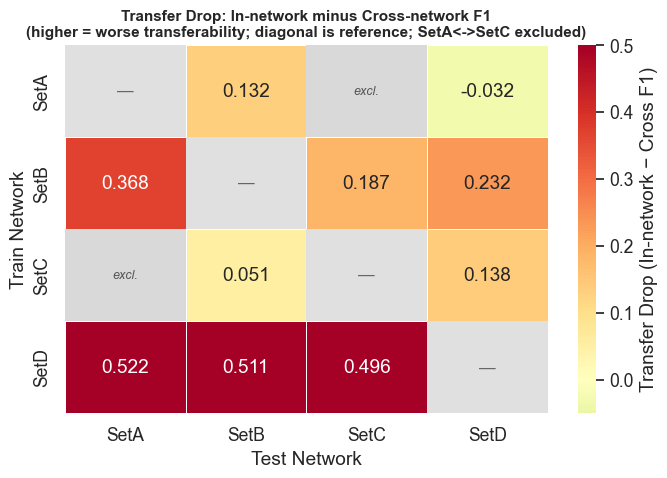

Saved Figure 3.


In [10]:
# ── Figure 3: Heatmap of Transfer Drop (In − Cross) per train × test pair ─────
# For each (train, test) off-diagonal pair: mean F1(train,test) vs mean F1(train,train)
f1_pair_avg = (avg_f1.groupby(['train_set', 'test_set'], as_index=False)
               ['mean_value'].mean())

# In-network baseline per train set
innet_base = (f1_pair_avg[f1_pair_avg['train_set'] == f1_pair_avg['test_set']]
              .set_index('train_set')['mean_value'])

# Compute drop: innet_base[train] - cross F1
drop_records = []
for _, row in f1_pair_avg.iterrows():
    if row['train_set'] == row['test_set']:
        drop = 0.0
    else:
        drop = innet_base[row['train_set']] - row['mean_value']
    drop_records.append({
        'train_set': row['train_set'],
        'test_set':  row['test_set'],
        'drop':      round(drop, 4)
    })

drop_df = pd.DataFrame(drop_records)
drop_pivot = drop_df.pivot(index='train_set', columns='test_set', values='drop')
drop_pivot = drop_pivot.reindex(index=NETWORKS, columns=NETWORKS)

fig, ax = plt.subplots(figsize=(7, 5))
annot = drop_pivot.round(3).astype(str)
for i in range(len(NETWORKS)):
    annot.iloc[i, i] = '—'

# Mask both the diagonal (reference) and the excluded SetA<->SetC cells
excl_mask = np.eye(len(NETWORKS), dtype=bool) | drop_pivot.isna().values
sns.heatmap(drop_pivot, annot=annot, fmt='', cmap='RdYlGn_r', center=0,
            vmin=-0.05, vmax=0.5, ax=ax, linewidths=0.5,
            mask=excl_mask,
            cbar_kws={'label': 'Transfer Drop (In-network − Cross F1)'})
# Overlay diagonal
for i in range(len(NETWORKS)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#e0e0e0', lw=0))
    ax.text(i + 0.5, i + 0.5, '—', ha='center', va='center',
            fontsize=12, color='#666')
# Overlay excluded SetA<->SetC cells
mark_excluded_cells(ax, NETWORKS, NETWORKS)

ax.set_title('Transfer Drop: In-network minus Cross-network F1\n'
             '(higher = worse transferability; diagonal is reference; '
             'SetA<->SetC excluded)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Test Network')
ax.set_ylabel('Train Network')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_heatmap_transfer_drop.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig3_heatmap_transfer_drop.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 3.")

Figure 3 is a heatmap of the transfer drop (In-network F1 − Cross-network F1) for every (train network, test network) pair. High values in a cell indicate that the model generalises poorly from that training source to that target network.

The next cell produces Figure 4, a per-model comparison of in-network vs cross-network F1. This reveals which model types are most robust to deployment on a network different from the one used for training.

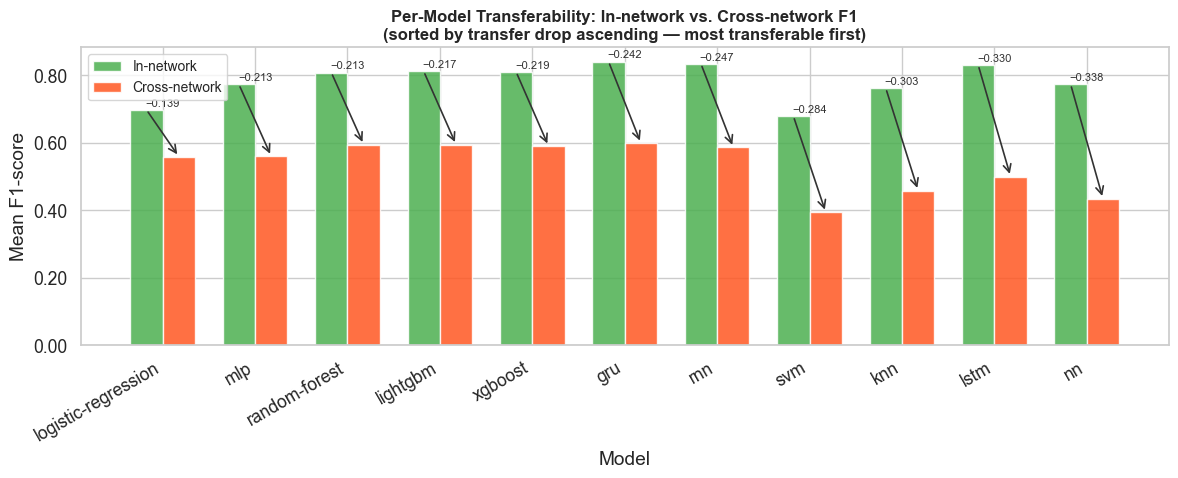

Saved Figure 4.


In [11]:
# ── Figure 4: Per-model transferability bar chart ─────────────────────────────
model_bar = (avg_f1.groupby(['model', 'eval_type'], as_index=False)['mean_value']
             .mean().rename(columns={'mean_value': 'Mean F1'}))

# Compute drop per model for sorting
model_drop = (model_bar.pivot(index='model', columns='eval_type', values='Mean F1')
              .reset_index())
model_drop.columns.name = None
model_drop['Transfer Drop'] = model_drop['In-network'] - model_drop['Cross-network']
model_order = model_drop.sort_values('Transfer Drop')['model'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(model_order))
width = 0.35

in_vals    = [model_drop.loc[model_drop['model']==m, 'In-network'].values[0]    for m in model_order]
cross_vals = [model_drop.loc[model_drop['model']==m, 'Cross-network'].values[0] for m in model_order]
drops      = [model_drop.loc[model_drop['model']==m, 'Transfer Drop'].values[0] for m in model_order]

bars_in    = ax.bar(x - width/2, in_vals,    width, label='In-network',    color=EVAL_PALETTE['In-network'],    alpha=0.85)
bars_cross = ax.bar(x + width/2, cross_vals, width, label='Cross-network', color=EVAL_PALETTE['Cross-network'], alpha=0.85)

# Annotate drop
for i, (iv, cv, drop) in enumerate(zip(in_vals, cross_vals, drops)):
    ax.annotate('', xy=(x[i]+width/2, cv), xytext=(x[i]-width/2, iv),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))
    ax.text(x[i], max(iv, cv) + 0.005, f'−{drop:.3f}', ha='center',
            va='bottom', fontsize=8, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=30, ha='right')
ax.set_ylabel('Mean F1-score')
ax.set_xlabel('Model')
ax.set_title('Per-Model Transferability: In-network vs. Cross-network F1\n'
             '(sorted by transfer drop ascending — most transferable first)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_bar_per_model_transferability.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig4_bar_per_model_transferability.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 4.")

Figure 4 displays a grouped bar chart with in-network and cross-network mean F1 per model, making it straightforward to rank models by their transferability and identify which architectures generalise best to unseen networks.

The next cell generates Figure 5, a dot-plot of Cohen's d effect sizes quantifying the practical magnitude of the transfer drop. It provides a measure of practical significance alongside the p-values in Table 4.

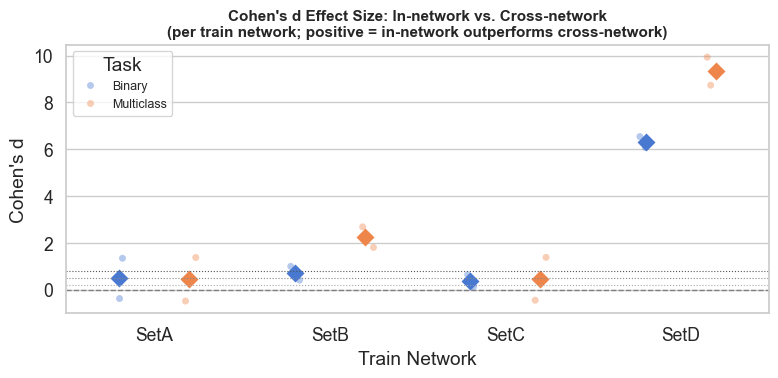

Saved Figure 5.


In [12]:
# ── Figure 5: Cohen's d effect size of transfer drop per train network ─────────
eff_plot = stat_df.drop_duplicates(['train_set', 'task', 'split']).copy()
eff_data = eff_plot.groupby(['train_set', 'task'])['cohens_d'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(data=eff_plot, x='train_set', y='cohens_d', hue='task',
              order=NETWORKS, dodge=True, jitter=True, alpha=0.4, ax=ax, size=5)
sns.pointplot(data=eff_data, x='train_set', y='cohens_d', hue='task',
              order=NETWORKS, dodge=0.4, markers='D',
              errorbar=None, ax=ax, linestyles='')
ax.axhline(0,   color='gray',  linestyle='--', linewidth=1)
ax.axhline(0.2, color='#aaa',  linestyle=':', linewidth=0.8, label='Small (0.2)')
ax.axhline(0.5, color='#888',  linestyle=':', linewidth=0.8, label='Medium (0.5)')
ax.axhline(0.8, color='#555',  linestyle=':', linewidth=0.8, label='Large (0.8)')
ax.set_title("Cohen's d Effect Size: In-network vs. Cross-network\n"
             "(per train network; positive = in-network outperforms cross-network)",
             fontsize=11, fontweight='bold')
ax.set_xlabel('Train Network')
ax.set_ylabel("Cohen's d")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Task', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_cohens_d_transfer.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig5_cohens_d_transfer.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 5.")

Figure 5 shows Cohen's d effect sizes for the in-network vs cross-network contrast per training network. Large effect sizes confirm that the performance degradation on transfer is not only statistically significant but also practically substantial.

## Summary: Answer to Q3

**Q3: "Are models transferable between networks?"**

The cell below prints a concise evidence summary based on statistical tests (Wilcoxon signed-rank, Cohen's d) across all models, networks, tasks, and splits.

The following cell computes and prints the quantitative evidence summary for Q3, consolidating the transfer drop statistics across models, splits, and network pairs.

In [13]:
# ── Q3 Evidence Summary ────────────────────────────────────────────────────────
overall_drop  = stat_df['transfer_drop'].mean()
pct_sig       = stat_df['significant'].mean() * 100
mean_d        = stat_df['cohens_d'].mean()

per_net_drop  = stat_df.groupby('train_set')['transfer_drop'].mean()

# Best and worst transferability pairs (off-diagonal)
off_diag = f1_pair_avg[f1_pair_avg['train_set'] != f1_pair_avg['test_set']].copy()
best_pair  = off_diag.loc[off_diag['mean_value'].idxmax()]
worst_pair = off_diag.loc[off_diag['mean_value'].idxmin()]

# Most and least transferable models
model_drop_series = (model_drop.set_index('model')['Transfer Drop']
                     .sort_values(ascending=True))

print("=" * 65)
print("Q3 EVIDENCE SUMMARY")
print("=" * 65)
print(f"Overall mean transfer drop (In − Cross F1) : {overall_drop:+.4f}")
print(f"% configurations p<0.05                    : {pct_sig:.1f}%")
print(f"Mean Cohen's d                             : {mean_d:.3f}")
print()
print("Per-train-network mean transfer drop:")
for net, drop in per_net_drop.items():
    severity = 'High' if drop > 0.1 else ('Medium' if drop > 0.05 else 'Low')
    print(f"  {net}: {drop:+.4f}  [{severity}]")
print()
print(f"Best  cross-network pair : {best_pair['train_set']}→{best_pair['test_set']}  "
      f"(F1={best_pair['mean_value']:.4f})")
print(f"Worst cross-network pair : {worst_pair['train_set']}→{worst_pair['test_set']}  "
      f"(F1={worst_pair['mean_value']:.4f})")
print()
print(f"Most transferable model  : {model_drop_series.index[0]:25s} "
      f"(drop={model_drop_series.iloc[0]:+.4f})")
print(f"Least transferable model : {model_drop_series.index[-1]:25s} "
      f"(drop={model_drop_series.iloc[-1]:+.4f})")
print()

if overall_drop > 0.1 and pct_sig > 50:
    conclusion = (
        "CONCLUSION: Models are NOT reliably transferable between networks. "
        "A significant and large transfer drop is observed for the majority of "
        "configurations, indicating that in-network training is required for "
        "high-quality DDoS detection."
    )
elif overall_drop > 0.05:
    conclusion = (
        "CONCLUSION: Models show limited transferability between networks. "
        "A moderate transfer drop exists, with substantial variation across "
        "network pairs and model types."
    )
else:
    conclusion = (
        "CONCLUSION: Models show reasonable transferability between networks, "
        "with only a small F1 drop when applied cross-network."
    )
print(conclusion)
print("=" * 65)

Q3 EVIDENCE SUMMARY
Overall mean transfer drop (In − Cross F1) : +0.2167
% configurations p<0.05                    : 68.8%
Mean Cohen's d                             : 2.552

Per-train-network mean transfer drop:
  SetA: +0.0639  [Medium]
  SetB: +0.2207  [High]
  SetC: +0.0549  [Medium]
  SetD: +0.5274  [High]

Best  cross-network pair : SetC→SetB  (F1=0.7017)
Worst cross-network pair : SetD→SetA  (F1=0.4030)

Most transferable model  : logistic-regression       (drop=+0.1386)
Least transferable model : nn                        (drop=+0.3385)

CONCLUSION: Models are NOT reliably transferable between networks. A significant and large transfer drop is observed for the majority of configurations, indicating that in-network training is required for high-quality DDoS detection.


This cell prints the final evidence summary: the overall mean in-network vs cross-network F1, the mean transfer drop, and the percentage of configurations where the drop is statistically significant. It synthesises all preceding analyses into the Q3 answer.

## Best Model Analysis

This section identifies the best model in two complementary regimes:
1. **Best in-network** — highest mean F1 when trained and evaluated on the same network.
2. **Best cross-network** — highest mean F1 when evaluated on a different network from training.
3. **Most transferable** — smallest transfer drop (In-network F1 − Cross-network F1).

Understanding which models best retain their performance across networks has direct implications
for practical DDoS detector deployment.

BEST MODEL ANALYSIS (Q3)

Model ranking by cross-network F1 (most transferable first):
                    model  Mean F1 (In-network)  Mean F1 (Cross-network)  Transfer Drop
Rank                                                                                   
1                     gru                0.8396                   0.5979         0.2417
2           random-forest                0.8072                   0.5940         0.2132
3                lightgbm                0.8105                   0.5939         0.2166
4                 xgboost                0.8088                   0.5897         0.2191
5                     rnn                0.8327                   0.5853         0.2473
6                     mlp                0.7721                   0.5592         0.2129
7     logistic-regression                0.6968                   0.5582         0.1386
8                    lstm                0.8291                   0.4992         0.3299
9                     knn        

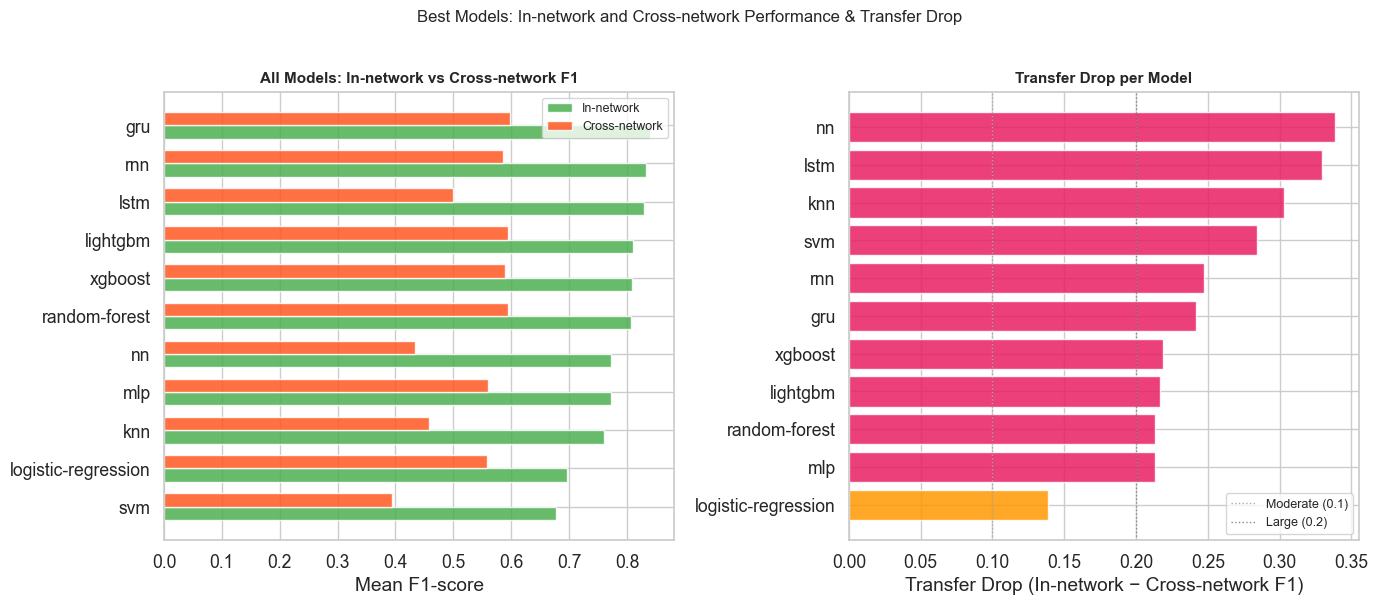


Saved best model analysis → figures/ and tables/


In [14]:
# ── Best Model Analysis (Q3) ─────────────────────────────────────────────────

# 1. Best model in-network
best_innet = (
    avg_f1[avg_f1['eval_type'] == 'In-network']
    .groupby('model')['mean_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1 (In-network)'})
)

# 2. Best model cross-network
best_cross = (
    avg_f1[avg_f1['eval_type'] == 'Cross-network']
    .groupby('model')['mean_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1 (Cross-network)'})
)

# 3. Combined with transfer drop
combined = best_innet.merge(best_cross, on='model')
combined['Transfer Drop'] = (
    combined['Mean F1 (In-network)'] - combined['Mean F1 (Cross-network)']
).round(4)
combined = combined.sort_values('Mean F1 (Cross-network)', ascending=False).reset_index(drop=True)
combined.index = range(1, len(combined) + 1)
combined.index.name = 'Rank'

print("=" * 65)
print("BEST MODEL ANALYSIS (Q3)")
print("=" * 65)
print("\nModel ranking by cross-network F1 (most transferable first):")
print(combined.round(4).to_string())

top_innet      = combined.sort_values('Mean F1 (In-network)', ascending=False).iloc[0]
top_cross      = combined.iloc[0]
smallest_drop  = combined.loc[combined['Transfer Drop'].abs().idxmin()]
print(f"\n  \u2192 Best in-network model     : {top_innet['model']}  "
      f"(F1 = {top_innet['Mean F1 (In-network)']:.4f})")
print(f"  \u2192 Best cross-network model   : {top_cross['model']}  "
      f"(F1 = {top_cross['Mean F1 (Cross-network)']:.4f})")
print(f"  \u2192 Smallest transfer drop      : {smallest_drop['model']}  "
      f"(drop = {smallest_drop['Transfer Drop']:+.4f})")

# Figure
top_n = len(combined)
sub   = combined.sort_values('Mean F1 (In-network)')
x     = np.arange(len(sub))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(x - width/2, sub['Mean F1 (In-network)'],   width,
             color='#4CAF50', alpha=0.85, label='In-network')
axes[0].barh(x + width/2, sub['Mean F1 (Cross-network)'], width,
             color='#FF5722', alpha=0.85, label='Cross-network')
axes[0].set_yticks(x)
axes[0].set_yticklabels(sub['model'].tolist())
axes[0].set_xlabel('Mean F1-score')
axes[0].set_title('All Models: In-network vs Cross-network F1', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

drop_sorted  = combined.sort_values('Transfer Drop', ascending=True)
colors_drop  = ['#2196F3' if v < 0.1 else ('#FF9800' if v < 0.2 else '#E91E63')
                for v in drop_sorted['Transfer Drop']]
axes[1].barh(drop_sorted['model'], drop_sorted['Transfer Drop'],
             color=colors_drop, alpha=0.85)
axes[1].axvline(0.1, color='#aaa', linestyle=':', linewidth=1, label='Moderate (0.1)')
axes[1].axvline(0.2, color='#888', linestyle=':', linewidth=1, label='Large (0.2)')
axes[1].set_xlabel('Transfer Drop (In-network \u2212 Cross-network F1)')
axes[1].set_title('Transfer Drop per Model', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Best Models: In-network and Cross-network Performance & Transfer Drop',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_best_models_transferability.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_models_transferability.png', bbox_inches='tight', dpi=150)
plt.show()

combined.round(4).reset_index().to_csv(TAB_DIR / 'best_model_transferability.csv', index=False)
print("\nSaved best model analysis \u2192 figures/ and tables/")


The best model analysis provides a complete ranking of all models by cross-network and in-network
F1, with the transfer drop shown for each. The grouped bar chart makes it easy to identify models
that maintain high performance both in-network and cross-network, while the right panel highlights
models whose performance degrades most severely when transferred to an unseen network.

## Case Study: Cross-Network Validation for Improved Transferability

The main Q3 analysis shows a large mean transfer drop (~0.28 F1) when models trained on
one network are tested on a different network — confirming that standard cross-network
generalisation is difficult.

This supplementary section asks: **can a model trained on one network, but validated on a
second network (cross-network validation), generalise better to held-out test networks?**

In the case study protocol:
- **Train set**: one network (model trained on its data)
- **Val set**: a different network (used only for model selection / early stopping)
- **Test sets**: two remaining networks (neither seen during training or validation)

By exposing the model to a second, unseen network during validation, the setup rewards
solutions that generalise across network distributions — a fundamentally different
inductive bias than within-network validation.

Q3 CASE STUDY: Cross-network Validation for Improved Transferability

Standard cross-network F1 (mean): 0.5323
Case study F1 (mean)            : 0.5929
Improvement ΔF1                 : +0.0606
Wilcoxon matched configs (n= 33): p=0.3575,  Cohen's d=0.025

Standard models : ['gru', 'knn', 'lightgbm', 'logistic-regression', 'lstm', 'mlp', 'nn', 'random-forest', 'rnn', 'svm', 'xgboost']
Case study models: ['catboost', 'cnn', 'gru', 'lightgbm', 'logistic-regression', 'random-forest', 'rnn', 'xgboost']
Common models   : ['gru', 'lightgbm', 'logistic-regression', 'random-forest', 'rnn', 'xgboost']

Per-test-set comparison:
  Network     Standard    Case study       ΔF1
  SetA          0.4207        0.3943   -0.0264
  SetB          0.5327        0.5570   +0.0243
  SetC          0.5239        0.6833   +0.1594
  SetD          0.6120        0.6611   +0.0490

Per-model comparison (common models):
  Model                        Standard    Case study       ΔF1
  gru                            0.59

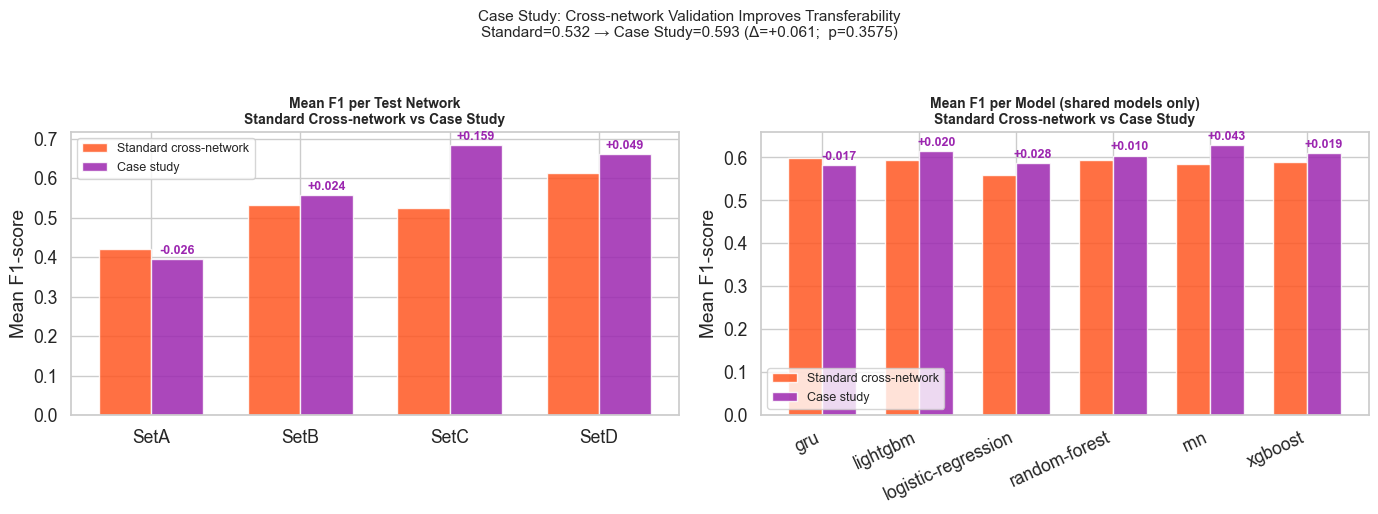


Saved case study transferability analysis → figures/ and tables/


In [15]:
# ── Q3 Case Study: Cross-network Validation for Improved Transferability ──────

CS_PATH = Path('../data/wandb_case_study.csv')
cs_raw  = pd.read_csv(CS_PATH)
cs_raw  = cs_raw[cs_raw['split'] != 'Random with same distribution'].copy()

# ── Melt to per-test-set F1 ───────────────────────────────────────────────────
cs_f1_cols = [c for c in cs_raw.columns
              if c.startswith('case_study/') and c.endswith('/f1_score')]

cs_long = cs_raw.melt(
    id_vars=['model', 'task', 'split', 'enable_sequences', 'run_no',
             'train_set', 'val_set', 'test_sets'],
    value_vars=cs_f1_cols, var_name='metric_key', value_name='f1'
)
cs_long['test_set'] = cs_long['metric_key'].str.extract(r'case_study/(\w+)/f1_score')
cs_long = cs_long.dropna(subset=['f1'])   # NaN = not a test set for this run

# Average across runs
cs_avg = (
    cs_long
    .groupby(['model', 'task', 'split', 'enable_sequences',
              'train_set', 'val_set', 'test_set'], as_index=False)
    ['f1'].mean()
    .rename(columns={'f1': 'mean_f1'})
)

# Exclude same-network/different-time transfers (SetA<->SetC) from the case study
cs_avg = drop_excluded_pairs(cs_avg)

# ── Standard cross-network F1 baseline (from existing avg_f1) ─────────────────
std_cross = avg_f1[avg_f1['eval_type'] == 'Cross-network'].copy()

cs_mean  = cs_avg['mean_f1'].mean()
std_mean = std_cross['mean_value'].mean()
delta    = cs_mean - std_mean

# ── Wilcoxon: match by (model, task, split, enable_sequences) ─────────────────
cs_config  = (
    cs_avg.groupby(['model', 'task', 'split', 'enable_sequences'])
    ['mean_f1'].mean().reset_index()
)
std_config = (
    std_cross.groupby(['model', 'task', 'split', 'enable_sequences'])
    ['mean_value'].mean().reset_index()
    .rename(columns={'mean_value': 'std_f1'})
)
paired = cs_config.merge(std_config, on=['model', 'task', 'split', 'enable_sequences'])

if len(paired) > 1:
    _, p_paired = wilcoxon(paired['mean_f1'].values, paired['std_f1'].values,
                           alternative='two-sided')
    d_paired = cohens_d(paired['mean_f1'].values, paired['std_f1'].values)
else:
    p_paired, d_paired = float('nan'), float('nan')

# ── Per-test-set breakdown ─────────────────────────────────────────────────────
cs_by_test  = cs_avg.groupby('test_set')['mean_f1'].mean()
std_by_test = std_cross.groupby('test_set')['mean_value'].mean()

# ── Per-model (models present in both datasets) ───────────────────────────────
COMMON_MODELS = sorted(
    set(cs_avg['model'].unique()) & set(std_cross['model'].unique())
)
cs_by_model  = (
    cs_avg[cs_avg['model'].isin(COMMON_MODELS)]
    .groupby('model')['mean_f1'].mean()
)
std_by_model = (
    std_cross[std_cross['model'].isin(COMMON_MODELS)]
    .groupby('model')['mean_value'].mean()
)

# ── Print summary ──────────────────────────────────────────────────────────────
print('=' * 70)
print('Q3 CASE STUDY: Cross-network Validation for Improved Transferability')
print('=' * 70)
print()
print(f'Standard cross-network F1 (mean): {std_mean:.4f}')
print(f'Case study F1 (mean)            : {cs_mean:.4f}')
print(f'Improvement \u0394F1                 : {delta:+.4f}')
print(f'Wilcoxon matched configs (n={len(paired):3d}): p={p_paired:.4f},  '
      f"Cohen's d={d_paired:.3f}")
print()
print(f'Standard models : {sorted(std_cross["model"].unique())}')
print(f'Case study models: {sorted(cs_avg["model"].unique())}')
print(f'Common models   : {COMMON_MODELS}')
print()
print('Per-test-set comparison:')
print(f'  {"Network":<8}  {"Standard":>10}  {"Case study":>12}  {"\u0394F1":>8}')
for net in NETWORKS:
    sv = float(std_by_test.get(net, float('nan')))
    cv = float(cs_by_test.get(net,  float('nan')))
    print(f'  {net:<8}  {sv:>10.4f}  {cv:>12.4f}  {cv-sv:>+8.4f}')
print()
print(f'Per-model comparison (common models):')
print(f'  {"Model":<25}  {"Standard":>10}  {"Case study":>12}  {"\u0394F1":>8}')
for m in COMMON_MODELS:
    sv = float(std_by_model.get(m, float('nan')))
    cv = float(cs_by_model.get(m,  float('nan')))
    print(f'  {m:<25}  {sv:>10.4f}  {cv:>12.4f}  {cv-sv:>+8.4f}')

# ── Figure ─────────────────────────────────────────────────────────────────────
CS_COLOR  = '#9C27B0'   # purple for case study
STD_COLOR = EVAL_PALETTE['Cross-network']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-test-set
nets  = NETWORKS
cs_v  = [float(cs_by_test.get(n,  0)) for n in nets]
std_v = [float(std_by_test.get(n, 0)) for n in nets]
x = np.arange(len(nets)); w = 0.35

axes[0].bar(x - w/2, std_v, w, color=STD_COLOR, alpha=0.85, label='Standard cross-network')
axes[0].bar(x + w/2, cs_v,  w, color=CS_COLOR,  alpha=0.85, label='Case study')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nets)
axes[0].set_ylabel('Mean F1-score')
axes[0].set_title('Mean F1 per Test Network\nStandard Cross-network vs Case Study',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
for i, (sv, cv) in enumerate(zip(std_v, cs_v)):
    if cv - sv != 0:
        axes[0].annotate(f'{cv-sv:+.3f}',
                         xy=(i + w/2, cv), xytext=(0, 4),
                         textcoords='offset points',
                         ha='center', fontsize=9, color=CS_COLOR, fontweight='bold')

# Right: per-model (common models)
m_labels = COMMON_MODELS
cs_m  = [float(cs_by_model.get(m,  0)) for m in m_labels]
std_m = [float(std_by_model.get(m, 0)) for m in m_labels]
x2 = np.arange(len(m_labels))

axes[1].bar(x2 - w/2, std_m, w, color=STD_COLOR, alpha=0.85, label='Standard cross-network')
axes[1].bar(x2 + w/2, cs_m,  w, color=CS_COLOR,  alpha=0.85, label='Case study')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(m_labels, rotation=25, ha='right')
axes[1].set_ylabel('Mean F1-score')
axes[1].set_title('Mean F1 per Model (shared models only)\nStandard Cross-network vs Case Study',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)
for i, (sv, cv) in enumerate(zip(std_m, cs_m)):
    if cv - sv != 0:
        axes[1].annotate(f'{cv-sv:+.3f}',
                         xy=(i + w/2, cv), xytext=(0, 4),
                         textcoords='offset points',
                         ha='center', fontsize=9, color=CS_COLOR, fontweight='bold')

sig_str = f'p={p_paired:.4f}' if not pd.isna(p_paired) else ''
plt.suptitle(
    f'Case Study: Cross-network Validation Improves Transferability\n'
    f'Standard={std_mean:.3f} \u2192 Case Study={cs_mean:.3f} '  
    f'(\u0394={delta:+.3f};  {sig_str})',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_case_study_transferability.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_case_study_transferability.png', bbox_inches='tight', dpi=150)
plt.show()

# Export
pd.DataFrame({
    'Network': nets,
    'Standard Cross-network F1': std_v,
    'Case Study F1': cs_v,
    'Improvement': [cv - sv for cv, sv in zip(cs_v, std_v)]
}).round(4).to_csv(TAB_DIR / 'cs_transferability_by_network.csv', index=False)

pd.DataFrame({
    'model': m_labels,
    'Standard Cross-network F1': std_m,
    'Case Study F1': cs_m,
    'Improvement': [cv - sv for cv, sv in zip(cs_m, std_m)]
}).round(4).to_csv(TAB_DIR / 'cs_transferability_by_model.csv', index=False)
print('\nSaved case study transferability analysis \u2192 figures/ and tables/')

The case study transferability analysis compares standard cross-network F1
(train on one network, test on another — no cross-network signal during training)
against the case study F1 (train on one network, validate on a second network,
test on two remaining networks).
The left panel shows the per-test-network improvement; the right panel shows
the per-model improvement for models present in both evaluation paradigms.
A consistent positive ΔF1 across networks and models indicates that cross-network
validation is an effective strategy to improve generalisation beyond what standard
single-network training can achieve.

# Paper visualizations

In [16]:
# ============================================================
# Q3 — Comprehensive transferability analysis
# All scripts in one cell block; run sequentially in the notebook.
# Assumes:
#   - raw CSV already loaded as `raw` (or loads it here)
#   - Directories Q3/figures/ and Q3/tables/ will be created
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import wilcoxon
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "serif",
})

DATA_PATH   = Path("../data/wandb_export_final_hyperparameters.csv")
FIG_DIR     = Path("figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR     = Path("tables");  TAB_DIR.mkdir(parents=True, exist_ok=True)

NETWORKS    = ["SetA", "SetB", "SetC", "SetD"]
DL_MODELS   = {"gru", "lstm", "rnn", "mlp", "nn"}
CLS_MODELS  = {"knn", "lightgbm", "logistic-regression", "random-forest", "svm", "xgboost"}
ALL_MODELS  = sorted(DL_MODELS | CLS_MODELS)
DL_COL      = "#2196F3"
CLS_COL     = "#FF9800"
NET_PALETTE = {"SetA": "#4878D0", "SetB": "#EE854A",
               "SetC": "#6ACC65", "SetD": "#D65F5F"}

# ── Load and tidy ─────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH)
raw = raw[raw["split"] != "Random with same distribution"].copy()

f1_cols = [c for c in raw.columns if c.endswith("/f1_score")]
id_cols = ["model", "task", "split", "enable_sequences", "run_no"]

long = raw.melt(id_vars=id_cols, value_vars=f1_cols,
                var_name="metric_key", value_name="f1")
long["train_set"] = long["metric_key"].str.extract(r"^(\w+)/")
long["test_set"]  = long["metric_key"].str.extract(r"/(\w+)/f1_score$")
long = long[long["train_set"].isin(NETWORKS) & long["test_set"].isin(NETWORKS)].copy()

# average over runs
avg = (long.groupby(["model", "task", "split", "enable_sequences",
                     "train_set", "test_set"])["f1"]
           .mean().reset_index().rename(columns={"f1": "mean_f1"}))
avg["category"] = avg["model"].map(
    lambda m: "Deep Learning" if m in DL_MODELS else "Classical ML")

# Exclude same-network/different-time transfers (SetA<->SetC) from cross views
avg = drop_excluded_pairs(avg)

in_net = avg[avg["train_set"] == avg["test_set"]].copy()
cross  = avg[avg["train_set"] != avg["test_set"]].copy()

def cohens_d(a, b):
    diff = np.asarray(a) - np.asarray(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)



In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# TAB Q3-1  Overall transferability summary
# ─────────────────────────────────────────────────────────────────────────────
records_t1 = []
for label, task_filter in [("Binary",     "Binary"),
                            ("Multiclass", "Multiclass"),
                            ("All",        None)]:
    in_sub = in_net  if task_filter is None else in_net[in_net["task"] == task_filter]
    cr_sub = cross   if task_filter is None else cross[cross["task"] == task_filter]
    mn_in  = in_sub["mean_f1"].mean()
    mn_cr  = cr_sub["mean_f1"].mean()
    drop   = mn_in - mn_cr
    rel    = drop / mn_in * 100
    # paired Wilcoxon: collapse to per-(model,task,split,net) for pairing
    in_g = in_sub.groupby(["model", "task", "split", "test_set"])["mean_f1"].mean().values
    cr_g = cr_sub.groupby(["model", "task", "split", "test_set"])["mean_f1"].mean().values
    n    = min(len(in_g), len(cr_g))
    p_val = d_val = np.nan
    if n > 1:
        try:
            _, p_val = wilcoxon(in_g[:n], cr_g[:n], alternative="two-sided")
            d_val    = cohens_d(in_g[:n], cr_g[:n])
        except Exception:
            pass
    records_t1.append({
        "Task": label,
        "In-network F1": round(mn_in, 4),
        "Cross-network F1": round(mn_cr, 4),
        "Transfer drop": round(drop, 4),
        "Relative drop (\\%)": round(rel, 1),
        "$p$-value": f"{p_val:.4f}" if not np.isnan(p_val) else "n/a",
        "Cohen's $d$": f"{d_val:.3f}" if not np.isnan(d_val) else "n/a",
    })

t1 = pd.DataFrame(records_t1)
print("=== Tab Q3-1: Overall transferability ===")
print(t1.to_string(index=False))

latex_t1 = t1.to_latex(index=False,
    caption=r"Overall transferability of ML-based DDoS detectors. "
            r"Macro F1-scores are averaged over all models, feature "
            r"approaches, and splits. Transfer drop = In-network $-$ "
            r"Cross-network. The \emph{All} row aggregates both tasks.",
    label="tab:q3_overall",
    column_format="lcccccc")
(TAB_DIR / "tab_q3_1_overall.tex").write_text(latex_t1)
print("Saved Tab Q3-1\n")


=== Tab Q3-1: Overall transferability ===
      Task  In-network F1  Cross-network F1  Transfer drop  Relative drop (\%) $p$-value Cohen's $d$
    Binary         0.8220            0.6066         0.2154                26.2    0.0000       1.732
Multiclass         0.7273            0.4580         0.2693                37.0    0.0000       2.225
       All         0.7747            0.5323         0.2423                31.3    0.0000       1.943
Saved Tab Q3-1



In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# TAB Q3-2  Full 4×4 directed transfer matrix (time-split, binary)
# Mean ± std across models, approaches, and runs
# ─────────────────────────────────────────────────────────────────────────────
for task_label in ["Binary", "Multiclass"]:
    sub = avg[avg["task"] == task_label]
    # --- mean F1 cell
    mu_df  = (sub.groupby(["train_set", "test_set"])["mean_f1"]
                 .agg(["mean", "std"]).reset_index())
    mu_df["cell"] = mu_df.apply(
        lambda r: f"${r['mean']:.3f}\\,{{\\pm}}\\,{r['std']:.3f}$"
                  if not np.isnan(r["std"]) else f"${r['mean']:.3f}$",
        axis=1)
    excl_mark = r"\textit{excl.}"
    pivot = (mu_df.pivot(index="train_set", columns="test_set", values="cell")
                  .reindex(index=NETWORKS, columns=NETWORKS)
                  .fillna(excl_mark))
    # mark diagonal bold
    for net in NETWORKS:
        if pivot.loc[net, net] != excl_mark:
            pivot.loc[net, net] = "\\textbf{" + pivot.loc[net, net] + "}"
    pivot.index.name = r"Train $\backslash$ Test"
    pivot.columns.name = None
    latex_t2 = pivot.to_latex(
        escape=False,
        caption=f"Directed cross-network transfer matrix, task: {task_label}. "
                r"Each cell reports mean\,$\pm$\,std Macro F1 averaged over all "
                r"models, feature approaches, splits, and runs. "
                r"Diagonal entries (in-network) are in \textbf{bold}. "
                r"SetA$\leftrightarrow$SetC transfers are excluded (same network, "
                r"different capture period) and marked \textit{excl.}",
        label=f"tab:q3_matrix_{task_label.lower()}",
        column_format="l" + "c" * len(NETWORKS))
    fname = f"tab_q3_2_transfer_matrix_{task_label.lower()}.tex"
    (TAB_DIR / fname).write_text(latex_t2)
    print(f"Saved Tab Q3-2 ({task_label})")


Saved Tab Q3-2 (Binary)
Saved Tab Q3-2 (Multiclass)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# TAB Q3-3  Per-model transferability, split by task (Binary / Multiclass).
#           "Mean" columns are aggregated across BOTH input representations and
#           all sets/splits/runs. The two "Best" columns report the model at its
#           best input representation (the one with the higher mean in-network
#           macro F1): the best representation's in-network and cross-network
#           means (aggregated across all sets) -> these match Table tab:q3_best_repr.
#           siunitx S-columns, makecell headers; best value per column bolded.
#           (Requires \usepackage{siunitx, makecell, booktabs} and xcolor's
#            [table] option for \rowcolors in the paper preamble.)
# ─────────────────────────────────────────────────────────────────────────────
MODEL_DISPLAY = {
    "gru": "GRU", "lstm": "LSTM", "rnn": "RNN", "mlp": "MLP", "nn": "NN",
    "knn": "kNN", "lightgbm": "LightGBM", "logistic-regression": "LR",
    "random-forest": "RandomForest", "svm": "SVM", "xgboost": "XGBoost",
}


def _fmt(val, is_best, dec):
    s = f"{val:.{dec}f}"
    return r"\textbf{" + s + "}" if is_best else s


HEADER = (
    r"    \textbf{Model} & {\makecell{\textbf{In-net mean} \\ \textbf{macro F1-score}}} & "
    r"{\makecell{\textbf{Cross-net mean} \\ \textbf{macro F1-score}}} & "
    r"{\makecell{\textbf{Transfer drop} \\ \textbf{(In $-$ Cross)}}} & "
    r"{\makecell{\textbf{Rel.} \\ \textbf{drop (\%)}}} & "
    r"{\makecell{\textbf{Best in-net} \\ \textbf{macro F1-score}}} & "
    r"{\makecell{\textbf{Best cross-net} \\ \textbf{macro F1-score}}} \\"
)

for task_label in ["Binary", "Multiclass"]:
    in_t = in_net[in_net["task"] == task_label]
    cr_t = cross[cross["task"] == task_label]

    rows = []
    for model in ALL_MODELS:
        im = in_t[in_t["model"] == model]["mean_f1"]   # both reps, all sets/splits/runs
        cm = cr_t[cr_t["model"] == model]["mean_f1"]
        if len(im) == 0 or len(cm) == 0:
            continue
        mn_in = im.mean(); mn_cr = cm.mean()
        drop  = mn_in - mn_cr
        rel   = drop / mn_in * 100 if mn_in > 0 else np.nan

        # Best representation = the one with the higher mean in-network F1;
        # report that representation's in-net and cross-net means (across all sets).
        best_in_rep, best_cr_rep, best_rep_score = np.nan, np.nan, -np.inf
        for seq in (False, True):
            imr = in_t[(in_t["model"] == model) & (in_t["enable_sequences"] == seq)]["mean_f1"]
            cmr = cr_t[(cr_t["model"] == model) & (cr_t["enable_sequences"] == seq)]["mean_f1"]
            if len(imr) == 0 or len(cmr) == 0:
                continue
            if imr.mean() > best_rep_score:
                best_rep_score = imr.mean()
                best_in_rep, best_cr_rep = imr.mean(), cmr.mean()

        rows.append({
            "model":      MODEL_DISPLAY.get(model, model),
            "in_mean":    round(mn_in, 4),
            "cross_mean": round(mn_cr, 4),
            "drop":       round(drop, 4),
            "rel":        round(rel, 1),
            "best_in":    round(best_in_rep, 4),
            "best_cross": round(best_cr_rep, 4),
        })

    dft = (pd.DataFrame(rows)
             .sort_values("cross_mean", ascending=False)
             .reset_index(drop=True))

    # Best value per column: higher is better, except drop/rel where lower is better
    best = {
        "in_mean":    dft["in_mean"].max(),
        "cross_mean": dft["cross_mean"].max(),
        "drop":       dft["drop"].min(),
        "rel":        dft["rel"].min(),
        "best_in":    dft["best_in"].max(),
        "best_cross": dft["best_cross"].max(),
    }

    body_lines = []
    for _, r in dft.iterrows():
        cells = [
            r["model"],
            _fmt(r["in_mean"],    r["in_mean"]    == best["in_mean"],    4),
            _fmt(r["cross_mean"], r["cross_mean"] == best["cross_mean"], 4),
            _fmt(r["drop"],       r["drop"]       == best["drop"],       4),
            _fmt(r["rel"],        r["rel"]        == best["rel"],        1),
            _fmt(r["best_in"],    r["best_in"]    == best["best_in"],    4),
            _fmt(r["best_cross"], r["best_cross"] == best["best_cross"], 4),
        ]
        body_lines.append("    " + " & ".join(cells) + r" \\")
    body = "\n".join(body_lines)

    caption = (
        r"Per-model transferability (" + task_label + r" task). The \emph{mean} "
        r"columns are aggregated across both input representations and all "
        r"training/test networks, splits, and runs. The \emph{Best} columns report "
        r"the model at its best input representation (highest mean in-network macro "
        r"F1): that representation's in-network and cross-network means. Transfer "
        r"drop = in-network mean $-$ cross-network mean. Rows sorted by cross-network "
        r"mean F1 descending. SetA$\leftrightarrow$SetC transfers are excluded (same "
        r"network, different capture period)."
    )

    latex = "\n".join([
        r"\begin{table*}",
        r"    \centering",
        r"    \caption{" + caption + r"}",
        r"    \label{tab:q3_per_model_" + task_label.lower() + r"}",
        r"",
        r"    \rowcolors{3}{gray!10}{white}",
        r"",
        r"    \begin{tabular}{",
        r"        l",
        r"        S[table-format=1.4]",
        r"        S[table-format=1.4]",
        r"        S[table-format=1.4]",
        r"        S[table-format=2.1]",
        r"        S[table-format=1.4]",
        r"        S[table-format=1.4]",
        r"    }",
        r"    \toprule",
        HEADER,
        r"    \midrule",
        body,
        r"    \bottomrule",
        r"    \end{tabular}",
        r"\end{table*}",
        r"",
    ])

    fname = f"tab_q3_3_per_model_{task_label.lower()}.tex"
    (TAB_DIR / fname).write_text(latex)
    print(f"=== Tab Q3-3 ({task_label}) — mean pooled; Best = best representation ===")
    print(dft.to_string(index=False))
    print(f"Saved {fname}\n")


=== Tab Q3-3 (Binary) — mean pooled; Best = best representation ===
       model  in_mean  cross_mean   drop  rel  best_in  best_cross
          LR   0.7757      0.7091 0.0666  8.6   0.8205      0.7345
         GRU   0.8827      0.6696 0.2130 24.1   0.8827      0.6696
    LightGBM   0.8383      0.6629 0.1754 20.9   0.9030      0.6666
         RNN   0.8786      0.6628 0.2158 24.6   0.8786      0.6628
     XGBoost   0.8392      0.6570 0.1822 21.7   0.9027      0.6507
RandomForest   0.8348      0.6568 0.1780 21.3   0.8953      0.6489
         MLP   0.8314      0.6185 0.2128 25.6   0.8314      0.6185
        LSTM   0.8715      0.5581 0.3134 36.0   0.8715      0.5581
         kNN   0.7993      0.5166 0.2827 35.4   0.8290      0.5032
          NN   0.8316      0.4678 0.3638 43.7   0.8316      0.4678
         SVM   0.7518      0.4653 0.2865 38.1   0.7568      0.4346
Saved tab_q3_3_per_model_binary.tex

=== Tab Q3-3 (Multiclass) — mean pooled; Best = best representation ===
       model  in_me

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# TAB Q3-4  Best-model per regime (in-network best vs cross-network best)
#           faceted by task × split
#
#  Two regimes compared side-by-side:
#    LEFT  — model with highest in-network mean F1, and what it achieves cross-net
#    RIGHT — model with highest cross-network mean F1, and what it achieves in-net
#
#  "Most transferable" is defined as highest absolute cross-network F1,
#  NOT smallest drop. A model that scores 0.40 in-net and 0.38 cross-net
#  (drop 0.02) is not more useful than one scoring 0.84 in-net and 0.58
#  cross-net (drop 0.26); the latter is far more valuable in deployment.
# ─────────────────────────────────────────────────────────────────────────────
records_t4 = []
for task in ["Binary", "Multiclass"]:
    for split in ["Random split", "Time split"]:
        in_sub = in_net[(in_net["task"] == task) & (in_net["split"] == split)]
        cr_sub = cross[(cross["task"]   == task) & (cross["split"] == split)]

        # ── best in-network model: highest mean in-net F1 ────────────────────
        bm_in         = in_sub.groupby("model")["mean_f1"].mean()
        best_in_model = bm_in.idxmax()
        best_in_f1    = bm_in.max()
        # what does that same model achieve cross-network?
        same_cr_f1    = cr_sub[cr_sub["model"] == best_in_model]["mean_f1"].mean()

        # ── best cross-network model: highest mean cross-net F1 ──────────────
        bm_cr         = cr_sub.groupby("model")["mean_f1"].mean()
        best_cr_model = bm_cr.idxmax()
        best_cr_f1    = bm_cr.max()
        # what does that same model achieve in-network?
        same_in_f1    = in_sub[in_sub["model"] == best_cr_model]["mean_f1"].mean()

        records_t4.append({
            "Task":  task,
            "Split": split,
            # left half
            "Best in-net model":           best_in_model,
            "In-net F1":                   round(best_in_f1,  4),
            "Cross-net F1 (same model)":   round(same_cr_f1,  4),
            "Drop":                        round(best_in_f1 - same_cr_f1, 4),
            # right half
            "Best cross-net model":        best_cr_model,
            "Cross-net F1":                round(best_cr_f1,  4),
            "In-net F1 (same model)":      round(same_in_f1,  4),
        })

t4 = pd.DataFrame(records_t4)
print("=== Tab Q3-4: Best model per regime ===")
print(t4.to_string(index=False))

latex_t4 = t4.to_latex(
    index=False,
    caption=(
        r"Best-model comparison per task and split condition. "
        r"\textit{Left half}: the model achieving the highest mean in-network "
        r"Macro F1, together with its cross-network F1 and the resulting drop -- "
        r"revealing how far the in-network champion falls when transferred. "
        r"\textit{Right half}: the model achieving the highest mean cross-network "
        r"Macro F1 (i.e.\ the best deployment candidate), together with its "
        r"in-network F1. The \emph{best cross-net model} column is determined "
        r"by absolute cross-network F1, not by transfer-drop magnitude, so that "
        r"a weakly performing but stable model cannot rank ahead of a strongly "
        r"performing model with a larger absolute drop."
    ),
    label="tab:q3_best_model",
    column_format="llccccccc",
)
(TAB_DIR / "tab_q3_4_best_model.tex").write_text(latex_t4)
print("Saved Tab Q3-4")

=== Tab Q3-4: Best model per regime ===
      Task        Split Best in-net model  In-net F1  Cross-net F1 (same model)   Drop Best cross-net model  Cross-net F1  In-net F1 (same model)
    Binary Random split               gru     0.9208                     0.6579 0.2629  logistic-regression        0.7185                  0.8040
    Binary   Time split               gru     0.8445                     0.6813 0.1632  logistic-regression        0.6998                  0.7475
Multiclass Random split          lightgbm     0.8570                     0.5120 0.3450                  gru        0.5254                  0.8478
Multiclass   Time split               gru     0.7452                     0.5270 0.2182        random-forest        0.5444                  0.7023
Saved Tab Q3-4


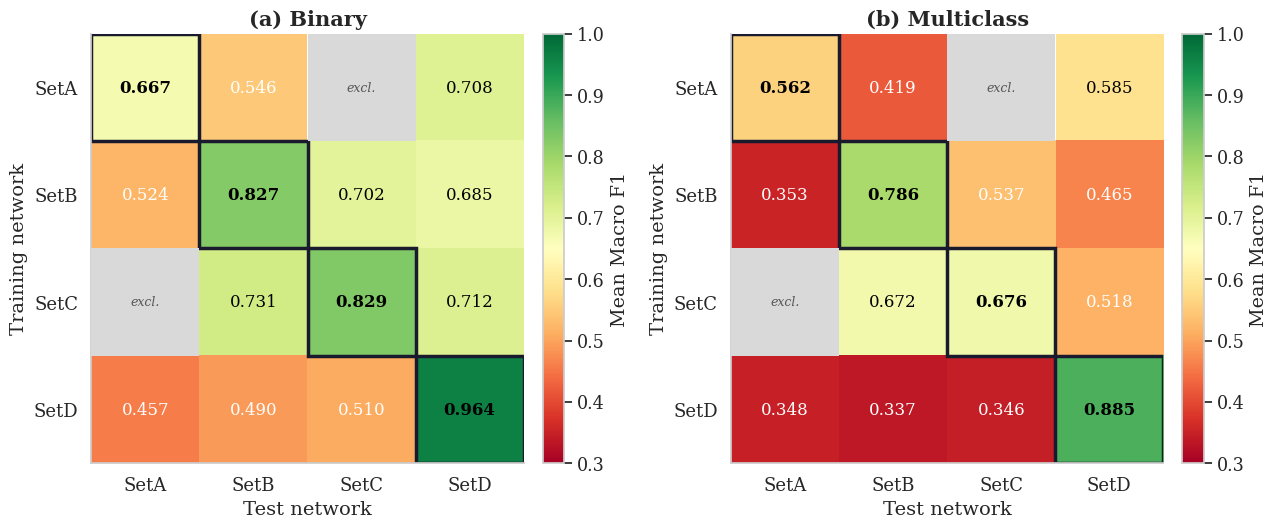

Saved Fig Q3-1



In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# FIG Q3-1  4×4 heatmap of mean macro F1 — binary and multiclass panels
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, task in zip(axes, ["Binary", "Multiclass"]):
    pivot = (avg[avg["task"] == task]
             .groupby(["train_set", "test_set"])["mean_f1"]
             .mean().reset_index()
             .pivot(index="train_set", columns="test_set", values="mean_f1")
             .reindex(index=NETWORKS, columns=NETWORKS))
    im = ax.imshow(pivot.values, vmin=0.3, vmax=1.0, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(NETWORKS))); ax.set_xticklabels(NETWORKS, fontsize=13)
    ax.set_yticks(range(len(NETWORKS))); ax.set_yticklabels(NETWORKS, fontsize=13)
    ax.set_xlabel("Test network", fontsize=14)
    ax.set_ylabel("Training network", fontsize=14)
    ax.set_title(f"({['a','b'][axes.tolist().index(ax)]}) {task}", fontsize=15, fontweight="bold")
    ax.grid(False)
    for i in range(len(NETWORKS)):
        for j in range(len(NETWORKS)):
            v = pivot.values[i, j]
            if np.isnan(v): continue
            fc = "white" if v < 0.55 else "black"
            weight = "bold" if i == j else "normal"
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    fontsize=12, color=fc, fontweight=weight)
        rect = plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                              fill=False, edgecolor="#1a1a2e", lw=2.5)
        ax.add_patch(rect)
    mark_excluded_cells(ax, NETWORKS, NETWORKS, style='imshow')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Mean Macro F1")
# fig.suptitle("Q3 — Mean Macro F1 transfer matrix\n"
#              "(bold diagonal = in-network; off-diagonal = cross-network)",
#              fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_q3_1_transfer_heatmap.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_q3_1_transfer_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Fig Q3-1\n")


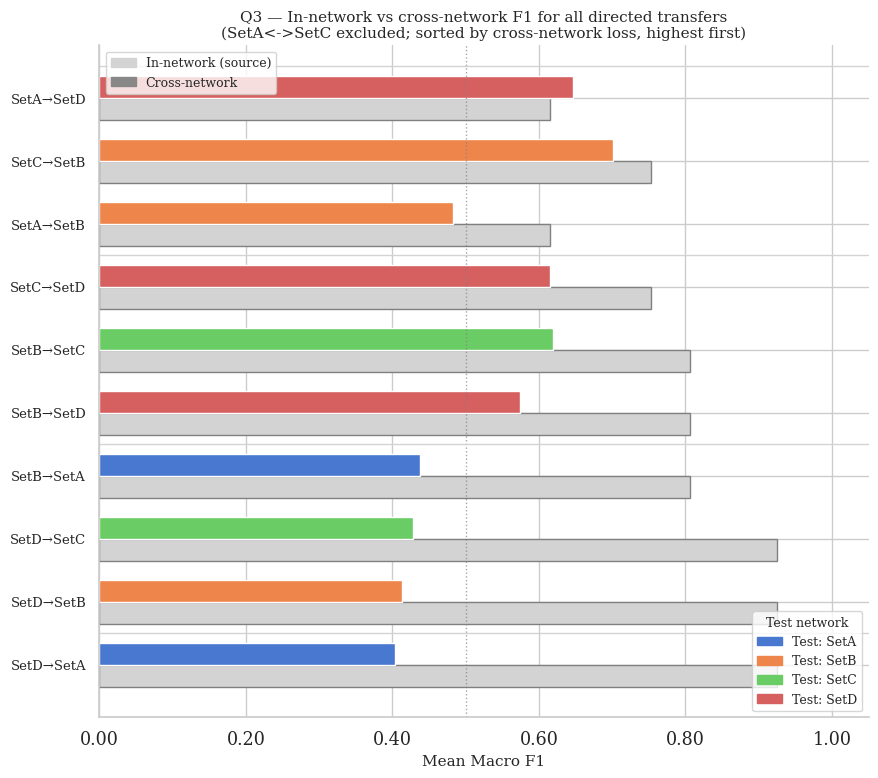

Saved Fig Q3-2


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# FIG Q3-2  Grouped horizontal bars — all directed transfers (SetA<->SetC excluded)
#           In-network F1 of the source (grey) vs cross-network F1
# ─────────────────────────────────────────────────────────────────────────────
from itertools import permutations

pairs_directed = [(a, b) for a, b in permutations(NETWORKS, 2)
                  if (a, b) not in EXCLUDED_PAIRS]

pair_f1 = (avg.groupby(["train_set", "test_set"])["mean_f1"]
              .mean().reset_index())
in_mean  = (in_net.groupby("train_set")["mean_f1"].mean())  # in-network of source

rows = []
for src, tgt in pairs_directed:
    cr_f1_val = pair_f1.loc[(pair_f1["train_set"]==src) &
                             (pair_f1["test_set"]==tgt), "mean_f1"]
    in_f1_val = in_mean.get(src, np.nan)
    rows.append({"direction": f"{src}→{tgt}",
                 "src": src, "tgt": tgt,
                 "in_f1": in_f1_val,
                 "cross_f1": float(cr_f1_val.values[0]) if len(cr_f1_val) else np.nan})
df_pairs = pd.DataFrame(rows).sort_values(["src", "tgt"]).reset_index(drop=True)

df_pairs["loss"] = df_pairs["in_f1"] - df_pairs["cross_f1"]
df_pairs = df_pairs.sort_values(["loss", "src", "tgt"], ascending=[True, False, False]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 8))
y = np.arange(len(df_pairs))
height = 0.35

ax.barh(y + height / 2, df_pairs["in_f1"], height=height,
    color="lightgrey", edgecolor="grey", label="In-network (source)")
ax.barh(y - height / 2, df_pairs["cross_f1"], height=height,
    color=[NET_PALETTE[t] for t in df_pairs["tgt"]],
    edgecolor="white", label="Cross-network")

ax.set_yticks(y)
ax.set_yticklabels(df_pairs["direction"], fontsize=9.5)
ax.invert_yaxis()
ax.set_xlabel("Mean Macro F1", fontsize=11)
ax.set_xlim(0.0, 1.05)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.axvline(0.5, color="grey", linestyle=":", lw=1, alpha=0.7)

net_patches = [mpatches.Patch(color=NET_PALETTE[n], label=f"Test: {n}") for n in NETWORKS]
leg1 = ax.legend(handles=net_patches, loc="lower right", fontsize=9,
         title="Test network", title_fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=[mpatches.Patch(color="lightgrey", label="In-network (source)"),
           mpatches.Patch(color="#888888", label="Cross-network")],
      loc="upper left", fontsize=9)

ax.set_title("Q3 — In-network vs cross-network F1 for all directed transfers\n"
         "(SetA<->SetC excluded; sorted by cross-network loss, highest first)",
         fontsize=11)

for i in range(0, len(df_pairs), 3):
    ax.axhline(i - 0.5, color="lightgrey", lw=1.0)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_q3_2_directed_transfers.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_q3_2_directed_transfers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Fig Q3-2")

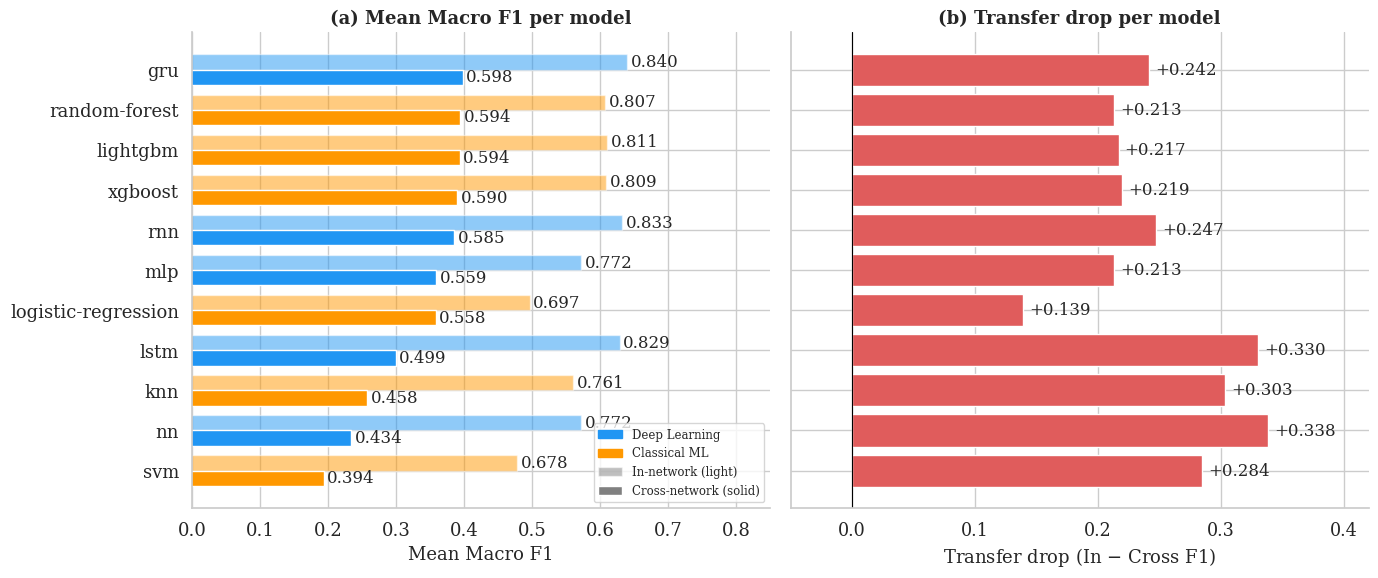

Saved Fig Q3-3



In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# FIG Q3-3  Per-model grouped bars (mean F1) + transfer drop panel
# ─────────────────────────────────────────────────────────────────────────────
mod_in  = in_net.groupby("model")["mean_f1"].mean()
mod_cr  = cross.groupby("model")["mean_f1"].mean()
mod_df  = (pd.DataFrame({"in_f1": mod_in, "cr_f1": mod_cr})
             .reset_index()
             .rename(columns={"index": "model", "model": "model"}))
mod_df["drop"]     = mod_df["in_f1"] - mod_df["cr_f1"]
mod_df["category"] = mod_df["model"].map(
    lambda m: "Deep Learning" if m in DL_MODELS else "Classical ML")
mod_df = mod_df.sort_values("cr_f1", ascending=True).reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
colors = [DL_COL if c == "Deep Learning" else CLS_COL for c in mod_df["category"]]
y = np.arange(len(mod_df))
w = 0.38

# left: in-network vs cross-network
ax1.barh(y + w/2, mod_df["in_f1"],  height=w, color=colors, alpha=0.5,
         edgecolor="white", label="In-network")
ax1.barh(y - w/2, mod_df["cr_f1"], height=w, color=colors,
         edgecolor="white", label="Cross-network")
ax1.set_yticks(y); ax1.set_yticklabels(mod_df["model"], fontsize=10)
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=13)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=13)
ax1.set_xlabel("Mean Macro F1", fontsize=13)
ax1.set_xlim(0.2, 1.05)
ax1.set_title("(a) Mean Macro F1 per model", fontsize=13, fontweight="bold")
dl_patch  = mpatches.Patch(color=DL_COL,  label="Deep Learning")
cls_patch = mpatches.Patch(color=CLS_COL, label="Classical ML")
in_patch  = mpatches.Patch(facecolor="grey", alpha=0.5, label="In-network (light)")
cr_patch  = mpatches.Patch(facecolor="grey",             label="Cross-network (solid)")
ax1.legend(handles=[dl_patch, cls_patch, in_patch, cr_patch],
           fontsize=8.5, loc="lower right")
for i, row in mod_df.iterrows():
    ax1.text(row["in_f1"] + 0.005, i + w/2, f"{row['in_f1']:.3f}",
             va="center", fontsize=12)
    ax1.text(row["cr_f1"] + 0.005, i - w/2, f"{row['cr_f1']:.3f}",
             va="center", fontsize=12)

# right: transfer drop
bar_colors = ["#e05c5c" if d > 0 else "#5cb85c" for d in mod_df["drop"]]
ax2.barh(y, mod_df["drop"], color=bar_colors, edgecolor="white")
ax2.axvline(0, color="black", lw=0.8)
ax2.set_xlabel("Transfer drop (In $-$ Cross F1)", fontsize=13)
ax2.set_title("(b) Transfer drop per model", fontsize=13, fontweight="bold")
ax2.set_xlim(-0.05, 0.42)
for i, row in mod_df.iterrows():
    x_pos = row["drop"] + 0.005 if row["drop"] >= 0 else row["drop"] - 0.005
    ha    = "left" if row["drop"] >= 0 else "right"
    ax2.text(x_pos, i, f"{row['drop']:+.3f}", va="center",
             ha=ha, fontsize=12)
# fig.suptitle("Q3 — Per-model in-network and cross-network performance\n"
#              "(sorted by cross-network F1 ascending)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_q3_3_per_model.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_q3_3_per_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Fig Q3-3\n")


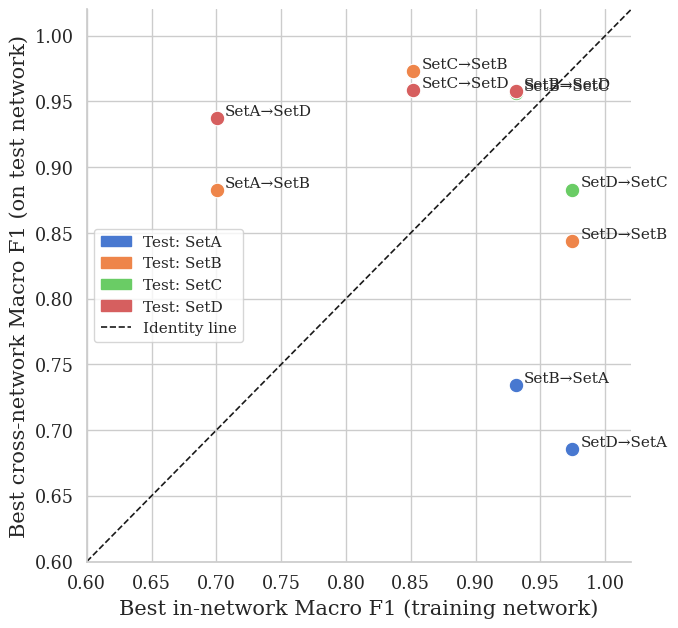

Saved Fig Q3-4

=== All Q3 figures and tables saved ===


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# FIG Q3-4  Scatter: best-model in-network F1 vs best-model cross-network F1
#           One point per directed network pair (12 points)
# ─────────────────────────────────────────────────────────────────────────────
# For each (train, test) pair: best in-net F1 of the train network,
# best cross-net F1 on that specific test network
best_in_net  = in_net.groupby(["train_set", "model"])["mean_f1"].mean().reset_index()
best_in_net  = (best_in_net.groupby("train_set")["mean_f1"].max()
                .reset_index().rename(columns={"mean_f1": "best_in_f1"}))
best_cr_pair = (cross.groupby(["train_set", "test_set"])["mean_f1"]
                .max().reset_index().rename(columns={"mean_f1": "best_cr_f1"}))
scatter_df   = best_cr_pair.merge(best_in_net, on="train_set")

fig, ax = plt.subplots(figsize=(7, 6.5))
for _, row in scatter_df.iterrows():
    c = NET_PALETTE.get(row["test_set"], "grey")
    ax.scatter(row["best_in_f1"], row["best_cr_f1"],
               color=c, s=110, zorder=3, edgecolors="white", lw=0.8)
    ax.annotate(f"{row['train_set']}→{row['test_set']}",
                (row["best_in_f1"], row["best_cr_f1"]),
                textcoords="offset points", xytext=(6, 2), fontsize=11)
lim = (0.6, 1.02)
ax.plot(lim, lim, "k--", lw=1.2, label="Identity (in-net = cross-net)", zorder=1)
ax.set_xlabel("Best in-network Macro F1 (training network)", fontsize=15)
ax.set_ylabel("Best cross-network Macro F1 (on test network)", fontsize=15)
ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.legend(handles=[mpatches.Patch(color=NET_PALETTE[n], label=f"Test: {n}")
                   for n in NETWORKS] +
                  [plt.Line2D([0],[0], color="k", linestyle="--", lw=1.2,
                               label="Identity line")],
          fontsize=11)
# ax.set_title("Q3 — Best-configuration cross-network F1 vs in-network F1\n"
#              "per directed transfer (12 train→test pairs)\n"
#              "Points below the identity line: cross-network performance is lower",
#              fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_q3_4_scatter_best_model.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_q3_4_scatter_best_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved Fig Q3-4\n")

print("=== All Q3 figures and tables saved ===")

## Input Representation Transferability

This section evaluates how well each **input representation** (component-based vs. sequence-based) transfers across networks. It reports (1) the overall mean in-network vs. cross-network macro F1 per representation — averaged over all models, tasks, splits, networks, and runs — as a high-level valuation of transferability (figure `q3_approach_and_bestmodel`), and (2) the best model per representation and task (the highest mean in-network configuration, averaged over runs) together with how it transfers cross-network (table). SetA↔SetC transfers are excluded throughout (same network, different capture period).

=== Overall input-representation transferability (mean over everything) ===
 Representation  In-network F1  Cross-network F1  Transfer drop  Relative drop (%)
Component-based         0.7244            0.5151         0.2094            28.9041
 Sequence-based         0.8021            0.5417         0.2603            32.4561


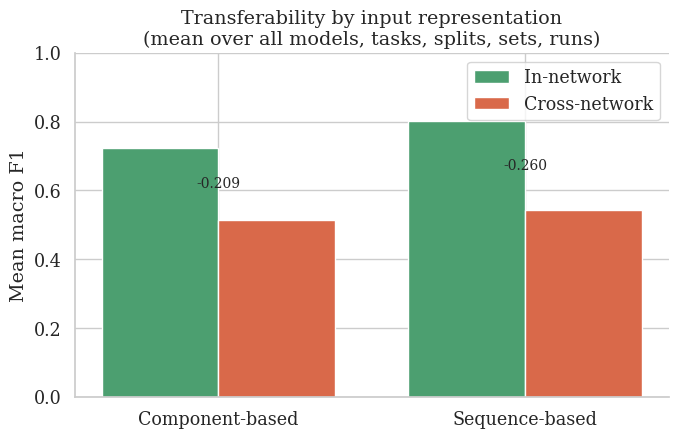

Saved figure q3_approach_and_bestmodel.(pdf|png)

=== Best model per input representation and task (mean over all sets) ===
 Representation       Task    Model  In-net F1  Cross-net F1  Transfer drop
Component-based     Binary  XGBoost     0.7757        0.6633         0.1125
Component-based Multiclass LightGBM     0.7250        0.4901         0.2349
 Sequence-based     Binary LightGBM     0.9030        0.6666         0.2363
 Sequence-based Multiclass LightGBM     0.8405        0.5596         0.2808

Saved tab_q3_best_model_per_representation.(tex|csv)


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Input-representation transferability
#   (1) Overall mean in-network vs cross-network F1 per representation
#       (mean over ALL models, tasks, splits, sets, runs) -> figure + numbers.
#   (2) Best model per (representation, task): the model with the highest mean
#       in-network macro F1 (aggregated across all sets, splits, and runs); its
#       in-network and cross-network F1 (both aggregated across all sets) and the
#       transfer drop are reported -> table for the text.
# Uses `avg` from the load cell (run-averaged; SetA<->SetC transfers excluded).
# ─────────────────────────────────────────────────────────────────────────────
APPROACHES = ["Component-based", "Sequence-based"]
TASKS      = ["Binary", "Multiclass"]
MODEL_DISPLAY = {
    "gru": "GRU", "lstm": "LSTM", "rnn": "RNN", "mlp": "MLP", "nn": "NN",
    "knn": "kNN", "lightgbm": "LightGBM", "logistic-regression": "LR",
    "random-forest": "RandomForest", "svm": "SVM", "xgboost": "XGBoost",
}

rep = avg.copy()
rep["approach"] = rep["enable_sequences"].map(
    {True: "Sequence-based", False: "Component-based"})
rep["kind"] = np.where(rep["train_set"] == rep["test_set"],
                       "In-network", "Cross-network")

# ── (1) Overall mean per representation (transferability valuation) ───────────
overall_rows = []
for ap in APPROACHES:
    sub = rep[rep["approach"] == ap]
    inn = sub.loc[sub["kind"] == "In-network",    "mean_f1"].mean()
    crs = sub.loc[sub["kind"] == "Cross-network", "mean_f1"].mean()
    overall_rows.append({"Representation": ap,
                         "In-network F1": inn, "Cross-network F1": crs,
                         "Transfer drop": inn - crs,
                         "Relative drop (%)": (inn - crs) / inn * 100})
overall_df = pd.DataFrame(overall_rows).round(4)
print("=== Overall input-representation transferability (mean over everything) ===")
print(overall_df.to_string(index=False))
overall_df.to_csv(TAB_DIR / "q3_representation_overall_transfer.csv", index=False)

GREEN, RED = "#4c9f70", "#d9694a"
fig, ax = plt.subplots(figsize=(7, 4.6))
x = np.arange(len(APPROACHES)); w = 0.38
ax.bar(x - w / 2, overall_df["In-network F1"],    w, label="In-network",    color=GREEN)
ax.bar(x + w / 2, overall_df["Cross-network F1"], w, label="Cross-network", color=RED)
for i, r in overall_df.iterrows():
    ax.annotate(f"-{r['Transfer drop']:.3f}",
                xy=(i, (r["In-network F1"] + r["Cross-network F1"]) / 2),
                ha="center", va="center", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(APPROACHES)
ax.set_ylabel("Mean macro F1"); ax.set_ylim(0, 1)
ax.set_title("Transferability by input representation\n"
             "(mean over all models, tasks, splits, sets, runs)")
ax.legend(loc="upper right")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"q3_approach_and_bestmodel.{ext}", dpi=150)
plt.show()
print("Saved figure q3_approach_and_bestmodel.(pdf|png)\n")

# ── (2) Best model per (representation, task), aggregated across all sets ─────
best_rows = []
for ap in APPROACHES:
    for task in TASKS:
        sub = rep[(rep["approach"] == ap) & (rep["task"] == task)]
        # per-model means aggregated across all sets / splits / runs
        stats = []
        for m in sub["model"].unique():
            sm = sub[sub["model"] == m]
            in_f1  = sm.loc[sm["kind"] == "In-network",    "mean_f1"].mean()
            cr_f1  = sm.loc[sm["kind"] == "Cross-network", "mean_f1"].mean()
            if np.isnan(in_f1) or np.isnan(cr_f1):
                continue
            stats.append((m, in_f1, cr_f1))
        if not stats:
            continue
        # best model = highest mean in-network F1 (aggregated across all sets)
        m, in_f1, cr_f1 = max(stats, key=lambda s: s[1])
        best_rows.append({
            "Representation": ap,
            "Task":           task,
            "Model":          MODEL_DISPLAY.get(m, m),
            "In-net F1":      round(in_f1, 4),
            "Cross-net F1":   round(cr_f1, 4),
            "Transfer drop":  round(in_f1 - cr_f1, 4),
        })

best_tbl = pd.DataFrame(best_rows)
print("=== Best model per input representation and task (mean over all sets) ===")
print(best_tbl.to_string(index=False))
best_tbl.to_csv(TAB_DIR / "tab_q3_best_model_per_representation.csv", index=False)

latex_best = best_tbl.to_latex(index=False, escape=True, float_format="%.4f",
    caption=(r"Best model per input representation and task. For each "
             r"(representation, task) the model with the highest mean in-network "
             r"macro F1 (aggregated across all networks, splits, and runs) is "
             r"selected; its in-network and cross-network macro F1 (both aggregated "
             r"across all sets) and transfer drop (in-network $-$ cross-network) are "
             r"reported. SetA$\leftrightarrow$SetC transfers are excluded (same "
             r"network, different capture period)."),
    label="tab:q3_best_repr",
    column_format="lllccc")
(TAB_DIR / "tab_q3_best_model_per_representation.tex").write_text(latex_best)
print("\nSaved tab_q3_best_model_per_representation.(tex|csv)")
